# Polar twist mPCN P vs rho sweep

Run mPCN across P in [10, 20, 30, 40] and rho in [0.0, 1.0] (step 0.05), with edge sweeps and cached diagnostics.

## Notebook summary (auto)
- Defines a 2D polar-twist forward map and Gaussian likelihood.
- Generates synthetic observations from a prior sample with additive noise.
- Configures mPCN/pCN sweeps over $\rho$ and $P$, plus diagnostics and caching.
- Runs chains, saves compressed samples/metrics, and reloads if present.
- Produces diagnostics/plots: proposal ellipses, traceplots, histograms, ESS/MSJD curves, rejection rates, and edge-$\rho$ zooms.
- Exports figures to reports/polar_twist and tables for ESS/MSJD.

In [6]:
import os
import sys
from pathlib import Path
import time
import json
import hashlib

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'pyproject.toml').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_path = repo_root / 'src'
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from multiproposal.algorithms.mpcn import mpcn_step, mpcn_chain
from multiproposal.algorithms.pcn import pcn_chain
from multiproposal.algorithms.mess import mess_step
from multiproposal.algorithms.effective_sample_size import estimate_effective_sample_size
# from multiproposal.problems.polar_twist import PolarTwist2D
from multiproposal.problems.toy_custom_likelihood import ToyCustomLikelihood2D
from multiproposal.utils.run_paths import format_float_tag
from multiproposal.plotting.figure_style import apply_pub_style
from multiproposal.plotting.sweep_plots import (
    plot_trace_grid,
    plot_ess_msjd_vs_rho,
    plot_ess_msjd_per_param_vs_rho,
    plot_rejection_vs_rho,
 )

In [7]:
def f_polar_twist(x, alpha, weight_x=1.0, weight_y=1.0):
    x1, x2 = x
    radius = np.sqrt(x1 ** 2 + x2 ** 2)
    comp1 = x1 * np.cos(alpha * weight_x * radius) - x2 * np.sin(alpha * weight_y * radius)
    comp2 = x1 * np.sin(alpha * weight_x * radius) + x2 * np.cos(alpha * weight_y * radius)
    return np.array([comp1, comp2])

def log_likelihood_polar_twist(x, y_obs, sigma=0.3, alpha=0.5, weight_x=1.0, weight_y=1.0):
    r = f_polar_twist(x, alpha=alpha, weight_x=weight_x, weight_y=weight_y) - y_obs
    return -0.5 * np.dot(r, r) / (sigma ** 2)

## Posterior formulation (polar twist)

Let $x = (x_1, x_2)^T \in \mathbb{R}^2$ and $r = \sqrt{x_1^2 + x_2^2}$. The forward map defined in the code is

$$
f(x;\alpha) = \begin{bmatrix}
x_1 \cos(\alpha r) - x_2 \sin(\alpha r) \\
x_1 \sin(\alpha r) + x_2 \cos(\alpha r)
\end{bmatrix}.
$$

The data are generated as

$$
x_{\text{true}} \sim \mathcal{N}(\mu, C), \quad y_{\text{obs}} = f(x_{\text{true}};\alpha) + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I_2),
$$

with $\mu = (0,0)^T$, $C = \text{prior\_std}^2 \begin{bmatrix}1 & 0.3 \\ 0.3 & 0.5\end{bmatrix}$ and $\text{prior\_std}=2.0$ (so $C = 4\begin{bmatrix}1 & 0.3 \\ 0.3 & 0.5\end{bmatrix}$), $\sigma = \text{sigma\_noise}=1.0$, and $\alpha = 2.0$ in this notebook.

The Gaussian likelihood implied by `log_likelihood_polar_twist` is

$$
p(y_{\text{obs}}\mid x) = (2\pi\sigma^2)^{-1}
\exp\left(-\frac{1}{2\sigma^2}\left\|f(x;\alpha)-y_{\text{obs}}\right\|^2\right).
$$

The prior density is

$$
p(x) = (2\pi)^{-1} |C|^{-1/2}
\exp\left(-\frac{1}{2}(x-\mu)^T C^{-1} (x-\mu)\right).
$$

Therefore the posterior is

$$
p(x\mid y_{\text{obs}}) \propto
\exp\left(-\frac{1}{2\sigma^2}\left\|f(x;\alpha)-y_{\text{obs}}\right\|^2
-\frac{1}{2}(x-\mu)^T C^{-1} (x-\mu)\right).
$$

Equivalently, the log-posterior (up to an additive constant) is

$$
\log p(x\mid y_{\text{obs}}) =
-\frac{1}{2\sigma^2}\left\|f(x;\alpha)-y_{\text{obs}}\right\|^2
-\frac{1}{2}(x-\mu)^T C^{-1} (x-\mu) + \text{const}.
$$

In [8]:
# Example used in the paper
alpha = 2
sigma_noise = 1.0
prior_std = 2.0
prior_cov = prior_std ** 2 * np.array([[1.0, 0.3], [0.3, 0.5]])
prior_mean = np.zeros(2)
weight_x = 1
weight_y = 1

# # Testing another example
# alpha = 2
# sigma_noise = 3.0
# prior_std = 0.5
# prior_cov = prior_std ** 2 * np.array([[1.0, 0.7], [0.7, 0.5]])
# prior_mean = np.zeros(2)
# weight_x = 0.3
# weight_y = 4

# # lots of bananas
# alpha = 0.4
# sigma_noise = 3.0
# prior_std = 3
# prior_cov = prior_std ** 2 * np.array([[1.0, 0.3], [0.3, 1]])
# prior_mean = np.zeros(2)
# weight_x = 0.3
# weight_y = 4

data_seed = 202
rng = np.random.default_rng(data_seed)
prior_sample = rng.multivariate_normal(prior_mean, prior_cov)
theta_true = f_polar_twist(prior_sample, alpha=alpha, weight_x=weight_x, weight_y=weight_y)
y_obs = theta_true + rng.normal(0.0, sigma_noise, size=theta_true.shape)

def log_likelihood(x):
    return log_likelihood_polar_twist(x, y_obs, sigma=sigma_noise, alpha=alpha, weight_x=weight_x, weight_y=weight_y)

problem = ToyCustomLikelihood2D(
    log_likelihood_fn=log_likelihood,
    prior_mean=prior_mean,
    prior_cov=prior_cov,
 )

data_config = {
    'model': 'polar_twist',
    'alpha': alpha,
    'weight_x': weight_x,
    'weight_y': weight_y,
    'sigma_noise': sigma_noise,
    'prior_std': prior_std,
    'prior_cov': prior_cov.tolist(),
    'prior_mean': prior_mean.tolist(),
    'data_seed': data_seed,
}

print('y_obs:', y_obs)
print('True x:', prior_sample)
print('Log-posterior at prior mean:', problem.log_posterior(prior_mean))

y_obs: [ 1.59110063 -3.32997972]
True x: [-3.13349585 -2.43303473]
Log-posterior at prior mean: -6.810183087048239


In [9]:
# Sweep configuration (used for file naming)
n_iters = 300000
P_list = [10, 30, 50, 100]
# P_list = [10]
M_list = P_list
rho_list = [round(val, 3) for val in np.arange(0, 1.01, 0.025)]
burn_in = 5000
max_lag = 5000
plot_iter = 0
n_diag_samples = 100
seed_base = 202
run_pcn = True
run_mess = False

algo_config = {
    'n_iters': n_iters,
    'burn_in': burn_in,
    'max_lag': max_lag,
    'n_diag_samples': n_diag_samples,
}
execution_config = {}
sweep_config = {
    'P_list': P_list,
    'M_list': M_list,
    'rho_list': rho_list,
    'seed_base': seed_base,
    'run_pcn': run_pcn,
    'run_mess': run_mess,
}

# Optional overrides to reuse an existing run directory exactly.
data_id_override = "data_h37adb6467e8e"
run_id_override = "mpcn_rho_sweep_h5c884eebabc6"

def _canonicalize_payload(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, dict):
        return {key: _canonicalize_payload(val) for key, val in sorted(obj.items())}
    if isinstance(obj, (list, tuple)):
        return [_canonicalize_payload(val) for val in obj]
    return obj

def _stable_hash(payload, length=12):
    data = json.dumps(
        _canonicalize_payload(payload),
        sort_keys=True,
        separators=(",", ":"),
        ensure_ascii=True,
    ).encode("utf-8")
    return hashlib.sha256(data).hexdigest()[:length]

data_id_config = dict(data_config)

data_id = data_id_override or f"data_h{_stable_hash(data_id_config)}"
run_id = run_id_override or f"mpcn_rho_sweep_h{_stable_hash({
    'algorithm': 'mpcn_rho_sweep',
    'algorithm_config': algo_config,
    'sweep': sweep_config,
})}"

estimations_dir = repo_root / "estimations" / "polar_twist" / data_id / "sweep" / run_id
reports_dir = repo_root / "reports" / "polar_twist" / data_id / "sweep" / run_id
for path in (estimations_dir, reports_dir):
    path.mkdir(parents=True, exist_ok=True)

run_config = {
    'dataset': 'polar_twist',
    'algorithm': 'mpcn_rho_sweep',
    'data': data_config,
    'algorithm_config': algo_config,
    'execution': execution_config,
    'sweep': sweep_config,
}
config_path = estimations_dir / "config.json"
if not config_path.exists():
    payload = dict(run_config)
    payload['data_id'] = data_id
    payload['run_id'] = run_id
    with open(config_path, 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2)

rng_init = np.random.default_rng(seed_base)
x0 = problem.sample_prior(rng_init)

print('P_list:', P_list)
print('M_list:', M_list)
print('rho_list:', rho_list)
print('n_iters:', n_iters)
print('burn_in:', burn_in)
print('max_lag:', max_lag)
print('n_diag_samples:', n_diag_samples)
print('data_id:', data_id)
print('run_id:', run_id)
print('Run directory:', estimations_dir)

P_list: [10, 30, 50, 100]
M_list: [10, 30, 50, 100]
rho_list: [np.float64(0.0), np.float64(0.025), np.float64(0.05), np.float64(0.075), np.float64(0.1), np.float64(0.125), np.float64(0.15), np.float64(0.175), np.float64(0.2), np.float64(0.225), np.float64(0.25), np.float64(0.275), np.float64(0.3), np.float64(0.325), np.float64(0.35), np.float64(0.375), np.float64(0.4), np.float64(0.425), np.float64(0.45), np.float64(0.475), np.float64(0.5), np.float64(0.525), np.float64(0.55), np.float64(0.575), np.float64(0.6), np.float64(0.625), np.float64(0.65), np.float64(0.675), np.float64(0.7), np.float64(0.725), np.float64(0.75), np.float64(0.775), np.float64(0.8), np.float64(0.825), np.float64(0.85), np.float64(0.875), np.float64(0.9), np.float64(0.925), np.float64(0.95), np.float64(0.975), np.float64(1.0)]
n_iters: 300000
burn_in: 5000
max_lag: 5000
n_diag_samples: 100
data_id: data_h37adb6467e8e
run_id: mpcn_rho_sweep_h5c884eebabc6
Run directory: /home/senng/multiproposal-internal/estimations

In [10]:
def compute_msjd_per_param(chain):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    jumps = np.diff(chain, axis=0)
    msjd = np.mean(jumps * jumps, axis=0)
    return msjd


def compute_ess_per_param(chain, max_lag):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    variances = np.var(chain, axis=0)
    if np.all(variances == 0):
        return np.zeros(chain.shape[1])
    ess_vals = estimate_effective_sample_size(chain, max_lag=max_lag)
    ess_vals = np.asarray(ess_vals, dtype=float)
    ess_vals[variances == 0] = 0.0
    return ess_vals


def summarize_chain_metrics(chain, runtime_sec, burn_in, max_lag):
    post = chain[burn_in:]
    ess_vals = compute_ess_per_param(post, max_lag=max_lag)
    msjd_vals = compute_msjd_per_param(post)
    ess_mean = float(np.nanmean(ess_vals)) if ess_vals.size else 0.0
    msjd_mean = float(np.nanmean(msjd_vals)) if msjd_vals.size else 0.0
    runtime_min = runtime_sec / 60.0
    ess_per_min = ess_mean / runtime_min if runtime_min > 0 else np.nan
    return {
        'runtime_sec': runtime_sec,
        'runtime_min': runtime_min,
        'ess_mean': ess_mean,
        'msjd_mean': msjd_mean,
        'ess_per_min': ess_per_min,
        'ess_per_param': ess_vals.tolist(),
        'msjd_per_param': msjd_vals.tolist(),
    }


def rho_to_tag(rho):
    return format_float_tag(rho, precision=5)


def chain_cache_paths(method, rho, seed_base, P=None):
    rho_tag = rho_to_tag(rho)
    if P is None:
        stem = f"{method}_rho{rho_tag}_seed{seed_base}"
    else:
        stem = f"{method}_P{P}_rho{rho_tag}_seed{seed_base}"
    chains_dir = estimations_dir / "chains"
    samples_path = chains_dir / f"{stem}.npz"
    metrics_path = chains_dir / f"{stem}_metrics.json"
    return samples_path, metrics_path


def mess_cache_paths(method, P, seed_base):
    stem = f"{method}_M{P}_seed{seed_base}"
    chains_dir = estimations_dir / "chains"
    samples_path = chains_dir / f"{stem}.npz"
    metrics_path = chains_dir / f"{stem}_metrics.json"
    return samples_path, metrics_path


def save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec):
    payload = dict(metrics)
    payload['accept_rate'] = None if accept_rate is None else float(accept_rate)
    payload['runtime_sec'] = float(runtime_sec)
    metrics_path.parent.mkdir(parents=True, exist_ok=True)
    with open(metrics_path, 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2)


def load_metrics_json(metrics_path):
    if not metrics_path.exists():
        return None
    with open(metrics_path, 'r', encoding='utf-8') as handle:
        return json.load(handle)


def save_chain_bundle(samples_path, metrics_path, chain, accept_rate, runtime_sec, metrics):
    samples_path.parent.mkdir(parents=True, exist_ok=True)
    accept_val = np.nan if accept_rate is None else float(accept_rate)
    np.savez_compressed(
        samples_path,
        chain=chain,
        accept_rate=accept_val,
        runtime_sec=float(runtime_sec),
    )
    save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec)


def load_chain_bundle(samples_path, metrics_path):
    if not samples_path.exists():
        return None
    data = np.load(samples_path, allow_pickle=False)
    chain = data['chain']
    accept_rate = float(data['accept_rate']) if 'accept_rate' in data else np.nan
    if np.isnan(accept_rate):
        accept_rate = None
    runtime_sec = float(data['runtime_sec']) if 'runtime_sec' in data else 0.0
    metrics = load_metrics_json(metrics_path)
    return chain, accept_rate, runtime_sec, metrics


def mpcn_diag_path(P, rho, seed_base):
    rho_tag = rho_to_tag(rho)
    diag_dir = estimations_dir / "diagnostics"
    return diag_dir / f"mpcn_P{P}_rho{rho_tag}_seed{seed_base}_diag.npz"


def save_mpcn_diagnostics(diag_path, snapshot, mean_dist_samples, mean_sq_dist_samples):
    if snapshot is None and (mean_dist_samples is None or len(mean_dist_samples) == 0):
        return
    diag_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        diag_path,
        snapshot=np.array(snapshot, dtype=object),
        mean_dist_samples=np.asarray(mean_dist_samples, dtype=float),
        mean_sq_dist_samples=np.asarray(mean_sq_dist_samples, dtype=float),
    )


def load_mpcn_diagnostics(diag_path):
    if not diag_path.exists():
        return None, np.asarray([], dtype=float), np.asarray([], dtype=float)
    data = np.load(diag_path, allow_pickle=True)
    snapshot = None
    if 'snapshot' in data:
        try:
            snapshot = data['snapshot'].item()
        except ValueError:
            snapshot = None
    mean_dist_samples = data['mean_dist_samples'] if 'mean_dist_samples' in data else np.asarray([], dtype=float)
    mean_sq_dist_samples = data['mean_sq_dist_samples'] if 'mean_sq_dist_samples' in data else np.asarray([], dtype=float)
    return snapshot, mean_dist_samples, mean_sq_dist_samples


def run_mpcn_chain(problem, x0, n_iters, rho, n_props, seed, diag_indices=None):
    rng = np.random.default_rng(seed)
    t0 = time.perf_counter()
    return_diag = diag_indices is not None
    if return_diag:
        chain, accepted_index, diagnostics = mpcn_chain(
            x0,
            problem,
            rng,
            n_iters,
            rho=rho,
            n_props=n_props,
            return_indices=True,
            return_diagnostics=True,
            diag_indices=diag_indices,
        )
    else:
        chain, accepted_index = mpcn_chain(
            x0,
            problem,
            rng,
            n_iters,
            rho=rho,
            n_props=n_props,
            return_indices=True,
        )
        diagnostics = None
    runtime_sec = time.perf_counter() - t0
    accept_rate = float(np.mean(accepted_index != 0))
    return chain, runtime_sec, accept_rate, diagnostics


def run_mess_chain(problem, x0, n_iters, M, seed, use_lp=False, distance_metric='angular', lam=0.0):
    rng = np.random.default_rng(seed)
    chain = np.zeros((n_iters + 1, problem.dim), dtype=float)
    chain[0] = x0
    x = x0.copy()
    t0 = time.perf_counter()
    for t in range(n_iters):
        x, _, _ = mess_step(
            x,
            problem,
            rng,
            M=M,
            use_lp=use_lp,
            distance_metric=distance_metric,
            lam=lam,
        )
        chain[t + 1] = x
    runtime_sec = time.perf_counter() - t0
    return chain, runtime_sec

In [11]:
# Precompute likelihood grid for plotting
grid_min = -8.0
grid_max = 8.0
grid = np.linspace(grid_min, grid_max, 300)
X1, X2 = np.meshgrid(grid, grid)
log_like = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x_grid = np.array([X1[i, j], X2[i, j]])
        log_like[i, j] = log_likelihood_polar_twist(x_grid, y_obs, sigma=sigma_noise, alpha=alpha, weight_x=weight_x, weight_y=weight_y)
log_like -= log_like.max()
like_density = np.exp(log_like)

theta = np.linspace(0.0, 2.0 * np.pi, 800)
levels_fill = 50
levels_line = 14

In [13]:
# Load cached sweep results (chains are generated by the jobs script)
results = {'mpcn': {}, 'pcn': {}, 'mess_uniform': {}, 'mess_euclid_sq': {}}
run_pcn = True
run_mess = False

missing = []
job_dir = repo_root / "jobs" / "polar_twist" / f"{run_id}_data_{data_id}"

if run_pcn:
    for rho in rho_list:
        samples_path, metrics_path = chain_cache_paths('pcn', rho=rho, seed_base=seed_base)
        loaded = load_chain_bundle(samples_path, metrics_path)
        if loaded is None:
            missing.append(f"pcn rho={rho:.3f}")
            continue
        chain, accept_rate, runtime_sec, metrics = loaded
        if metrics is None or 'ess_per_param' not in metrics:
            metrics = summarize_chain_metrics(
                chain, runtime_sec, burn_in=burn_in, max_lag=max_lag
            )
            save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec)
        results['pcn'][rho] = {
            'chain': chain,
            'runtime_sec': runtime_sec,
            'accept_rate': accept_rate,
            'metrics': metrics,
        }
        accept_display = np.nan if accept_rate is None else accept_rate
        print(
            f'pCN loaded: rho={rho:.3f}, accept={accept_display:.3f}, runtime={runtime_sec:.2f}s'
        )
else:
    print('pCN disabled (run_pcn=False).')

for P in P_list:
    results['mpcn'][P] = {}
    for rho in rho_list:
        samples_path, metrics_path = chain_cache_paths('mpcn', rho=rho, seed_base=seed_base, P=P)
        diag_path = mpcn_diag_path(P, rho, seed_base)
        loaded = load_chain_bundle(samples_path, metrics_path)
        if loaded is None:
            missing.append(f"mpcn P={P} rho={rho:.3f}")
            continue
        chain, accept_rate, runtime_sec, metrics = loaded
        if metrics is None or 'ess_per_param' not in metrics:
            metrics = summarize_chain_metrics(
                chain, runtime_sec, burn_in=burn_in, max_lag=max_lag
            )
            save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec)
        snapshot, mean_dist_samples, mean_sq_dist_samples = load_mpcn_diagnostics(diag_path)
        results['mpcn'][P][rho] = {
            'chain': chain,
            'runtime_sec': runtime_sec,
            'accept_rate': accept_rate,
            'metrics': metrics,
            'snapshot': snapshot,
            'mean_dist_samples': np.asarray(mean_dist_samples, dtype=float),
            'mean_sq_dist_samples': np.asarray(mean_sq_dist_samples, dtype=float),
        }
        accept_display = np.nan if accept_rate is None else accept_rate
        print(
            f'mPCN loaded: P={P}, rho={rho:.3f}, accept={accept_display:.3f}, runtime={runtime_sec:.2f}s'
        )

    if run_mess:
        samples_path, metrics_path = mess_cache_paths('mess_uniform', P=P, seed_base=seed_base)
        loaded = load_chain_bundle(samples_path, metrics_path)
        if loaded is None:
            missing.append(f"mess_uniform M={P}")
        else:
            mess_chain, _, mess_runtime, mess_metrics = loaded
            if mess_metrics is None or 'ess_per_param' not in mess_metrics:
                mess_metrics = summarize_chain_metrics(
                    mess_chain, mess_runtime, burn_in=burn_in, max_lag=max_lag
                )
                save_metrics_json(metrics_path, mess_metrics, None, mess_runtime)
            results['mess_uniform'][P] = {
                'chain': mess_chain,
                'runtime_sec': mess_runtime,
                'metrics': mess_metrics,
            }
            print(f'MESS uniform loaded: M={P}, runtime={mess_runtime:.2f}s')

        samples_path, metrics_path = mess_cache_paths('mess_euclid_sq', P=P, seed_base=seed_base)
        loaded = load_chain_bundle(samples_path, metrics_path)
        if loaded is None:
            missing.append(f"mess_euclid_sq M={P}")
        else:
            mess_lp_chain, _, mess_lp_runtime, mess_lp_metrics = loaded
            if mess_lp_metrics is None or 'ess_per_param' not in mess_lp_metrics:
                mess_lp_metrics = summarize_chain_metrics(
                    mess_lp_chain, mess_lp_runtime, burn_in=burn_in, max_lag=max_lag
                )
                save_metrics_json(metrics_path, mess_lp_metrics, None, mess_lp_runtime)
            results['mess_euclid_sq'][P] = {
                'chain': mess_lp_chain,
                'runtime_sec': mess_lp_runtime,
                'metrics': mess_lp_metrics,
            }
            print(f'MESS euclid_sq loaded: M={P}, runtime={mess_lp_runtime:.2f}s')
    else:
        results['mess_uniform'][P] = None
        results['mess_euclid_sq'][P] = None
        print(f'MESS disabled for M={P} (run_mess=False).')

if missing:
    preview = "\n".join(missing[:10])
    raise RuntimeError(
        "Missing chain outputs. Run the job script to generate chains, then re-run this cell.\n"
        f"Job dir: {job_dir}\n"
        f"Example: bash {job_dir / 'launch_workers.sh'}\n"
        f"Missing ({len(missing)}):\n{preview}"
    )

pCN loaded: rho=0.000, accept=0.108, runtime=7.97s
pCN loaded: rho=0.025, accept=0.108, runtime=5.88s
pCN loaded: rho=0.050, accept=0.109, runtime=5.54s
pCN loaded: rho=0.075, accept=0.107, runtime=5.66s
pCN loaded: rho=0.100, accept=0.109, runtime=5.57s
pCN loaded: rho=0.125, accept=0.110, runtime=5.60s
pCN loaded: rho=0.150, accept=0.110, runtime=5.61s
pCN loaded: rho=0.175, accept=0.110, runtime=5.65s
pCN loaded: rho=0.200, accept=0.111, runtime=5.70s
pCN loaded: rho=0.225, accept=0.111, runtime=5.60s
pCN loaded: rho=0.250, accept=0.112, runtime=5.63s
pCN loaded: rho=0.275, accept=0.114, runtime=5.63s
pCN loaded: rho=0.300, accept=0.113, runtime=5.71s
pCN loaded: rho=0.325, accept=0.115, runtime=5.68s
pCN loaded: rho=0.350, accept=0.116, runtime=5.90s
pCN loaded: rho=0.375, accept=0.117, runtime=5.71s
pCN loaded: rho=0.400, accept=0.117, runtime=5.80s
pCN loaded: rho=0.425, accept=0.119, runtime=5.84s
pCN loaded: rho=0.450, accept=0.119, runtime=5.64s
pCN loaded: rho=0.475, accept=0

In [10]:
# def plot_mpcn_snapshot(ax, snapshot, P, rho, iter_idx):
#     mu = problem.prior_mean()
#     x = snapshot['x']
#     nu_c = snapshot['nu_c']
#     props = snapshot['props']
#     candidates = snapshot['candidates']
#     logy = snapshot['logy']
#     accepted_idx = snapshot['accepted_idx']
#     mean_dist = snapshot['mean_dist']
#     mean_sq_dist = snapshot['mean_sq_dist']
#     ellipse = mu + np.cos(theta)[:, None] * (x - mu) + np.sin(theta)[:, None] * nu_c

#     ax.contourf(X1, X2, like_density, levels=levels_fill, cmap='Greys', alpha=0.35)
#     ax.contour(X1, X2, like_density, levels=levels_line, colors='black', linewidths=0.5, alpha=0.2)
#     ax.plot(ellipse[:, 0], ellipse[:, 1], color='black', linewidth=1.5, zorder=2)

#     prop_log_like = np.array([problem.log_likelihood(p) for p in props])
#     above = prop_log_like >= logy
#     ax.scatter(props[~above, 0], props[~above, 1], color='teal', s=10, alpha=0.8, label='props < logy', zorder=2)
#     ax.scatter(props[above, 0], props[above, 1], color='teal', s=10, alpha=0.8, label='props >= logy', zorder=2)
#     ax.scatter([x[0]], [x[1]], color='green', s=60, marker='o', label='current', zorder=3)
#     accepted_point = candidates[accepted_idx]
#     ax.scatter([accepted_point[0]], [accepted_point[1]], facecolors='none', edgecolors='black',
#                s=120, marker='s', linewidths=1.8, label='accepted', zorder=4)
#     ax.text(
#         0.02,
#         0.98,
#         f'mean dist: {mean_dist:.3f}\nmean sq dist: {mean_sq_dist:.3f}',
#         transform=ax.transAxes,
#         va='top',
#         ha='left',
#         fontsize=9,
#         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
#     )
#     ax.set_aspect('equal', adjustable='box')
#     ax.set_xlabel('x1')
#     ax.set_ylabel('x2')
#     ax.grid(False)
#     ax.set_title(f'P={P}, rho={rho:.3f}, iter={iter_idx}')


# reports_dir.mkdir(parents=True, exist_ok=True)

# # Ellipse plots: one figure per P, subplots by rho
# n_rho = len(rho_list)
# ncols = 3
# nrows = int(np.ceil(n_rho / ncols))

# for P in P_list[-1:]:
#     fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.0 * nrows), sharex=True, sharey=True)
#     axes = np.array(axes).reshape(-1)
#     for ax, rho in zip(axes, rho_list):
#         snapshot = results['mpcn'][P][rho]['snapshot']
#         if snapshot is None:
#             ax.text(
#                 0.5,
#                 0.5,
#                 'No snapshot loaded',
#                 transform=ax.transAxes,
#                 ha='center',
#                 va='center',
#                 fontsize=10,
#             )
#             ax.set_aspect('equal', adjustable='box')
#             ax.set_title(f'P={P}, rho={rho:.3f}, iter={plot_iter}')
#             ax.axis('off')
#             continue
#         plot_mpcn_snapshot(ax, snapshot, P, rho, plot_iter)
#     for ax in axes[len(rho_list):]:
#         ax.axis('off')
#     fig.suptitle(f'mPCN proposal ellipses (P={P})')
#     fig.tight_layout()
#     fig.savefig(
#         reports_dir / f'03_polar_twist_mpcn_ellipses_P{P}_seed{seed_base}_wx{weight_x_tag}_wy{weight_y_tag}.png',
#         dpi=300,
#         bbox_inches='tight',
#     )
#     plt.show()

In [11]:
# # Distance summaries vs rho (one curve per P)
# P_sorted = sorted(P_list)
# colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(P_sorted)))
# color_by_P = {P: colors[i] for i, P in enumerate(P_sorted)}

# fig, ax = plt.subplots(figsize=(7, 4))
# for P in P_list:
#     dist_vals = [np.mean(results['mpcn'][P][rho]['mean_dist_samples']) for rho in rho_list]
#     ax.plot(rho_list, dist_vals, marker='o', color=color_by_P[P], label=f'P={P}')
# ax.set_xlabel('rho')
# ax.set_ylabel('Mean distance to center (avg over samples)')
# ax.set_title('Polar twist: mean distance vs rho (mPCN)')
# ax.grid(alpha=0.3)
# ax.legend(loc='best')
# plt.show()

# for P in P_list:
#     fig, ax = plt.subplots(figsize=(8, 4))
#     dist_samples = [results['mpcn'][P][rho]['mean_dist_samples'] for rho in rho_list]
#     ax.boxplot(dist_samples, widths=0.6, showfliers=False)
#     ax.set_xticks(np.arange(1, len(rho_list) + 1))
#     ax.set_xticklabels([f'{rho:.1f}' for rho in rho_list])
#     ax.set_xlabel('rho')
#     ax.set_ylabel('Mean distance to center (per step)')
#     ax.set_title(f'Polar twist: mean distance distribution (P={P})')
#     ax.grid(alpha=0.3, axis='y')
#     plt.show()

# fig, ax = plt.subplots(figsize=(7, 4))
# for P in P_list:
#     dist_vals = [np.mean(results['mpcn'][P][rho]['mean_sq_dist_samples']) for rho in rho_list]
#     ax.plot(rho_list, dist_vals, marker='o', color=color_by_P[P], label=f'P={P}')
# ax.set_xlabel('rho')
# ax.set_ylabel('Mean squared distance to center (avg over samples)')
# ax.set_title('Polar twist: mean squared distance vs rho (mPCN)')
# ax.grid(alpha=0.3)
# ax.legend(loc='best')
# plt.show()

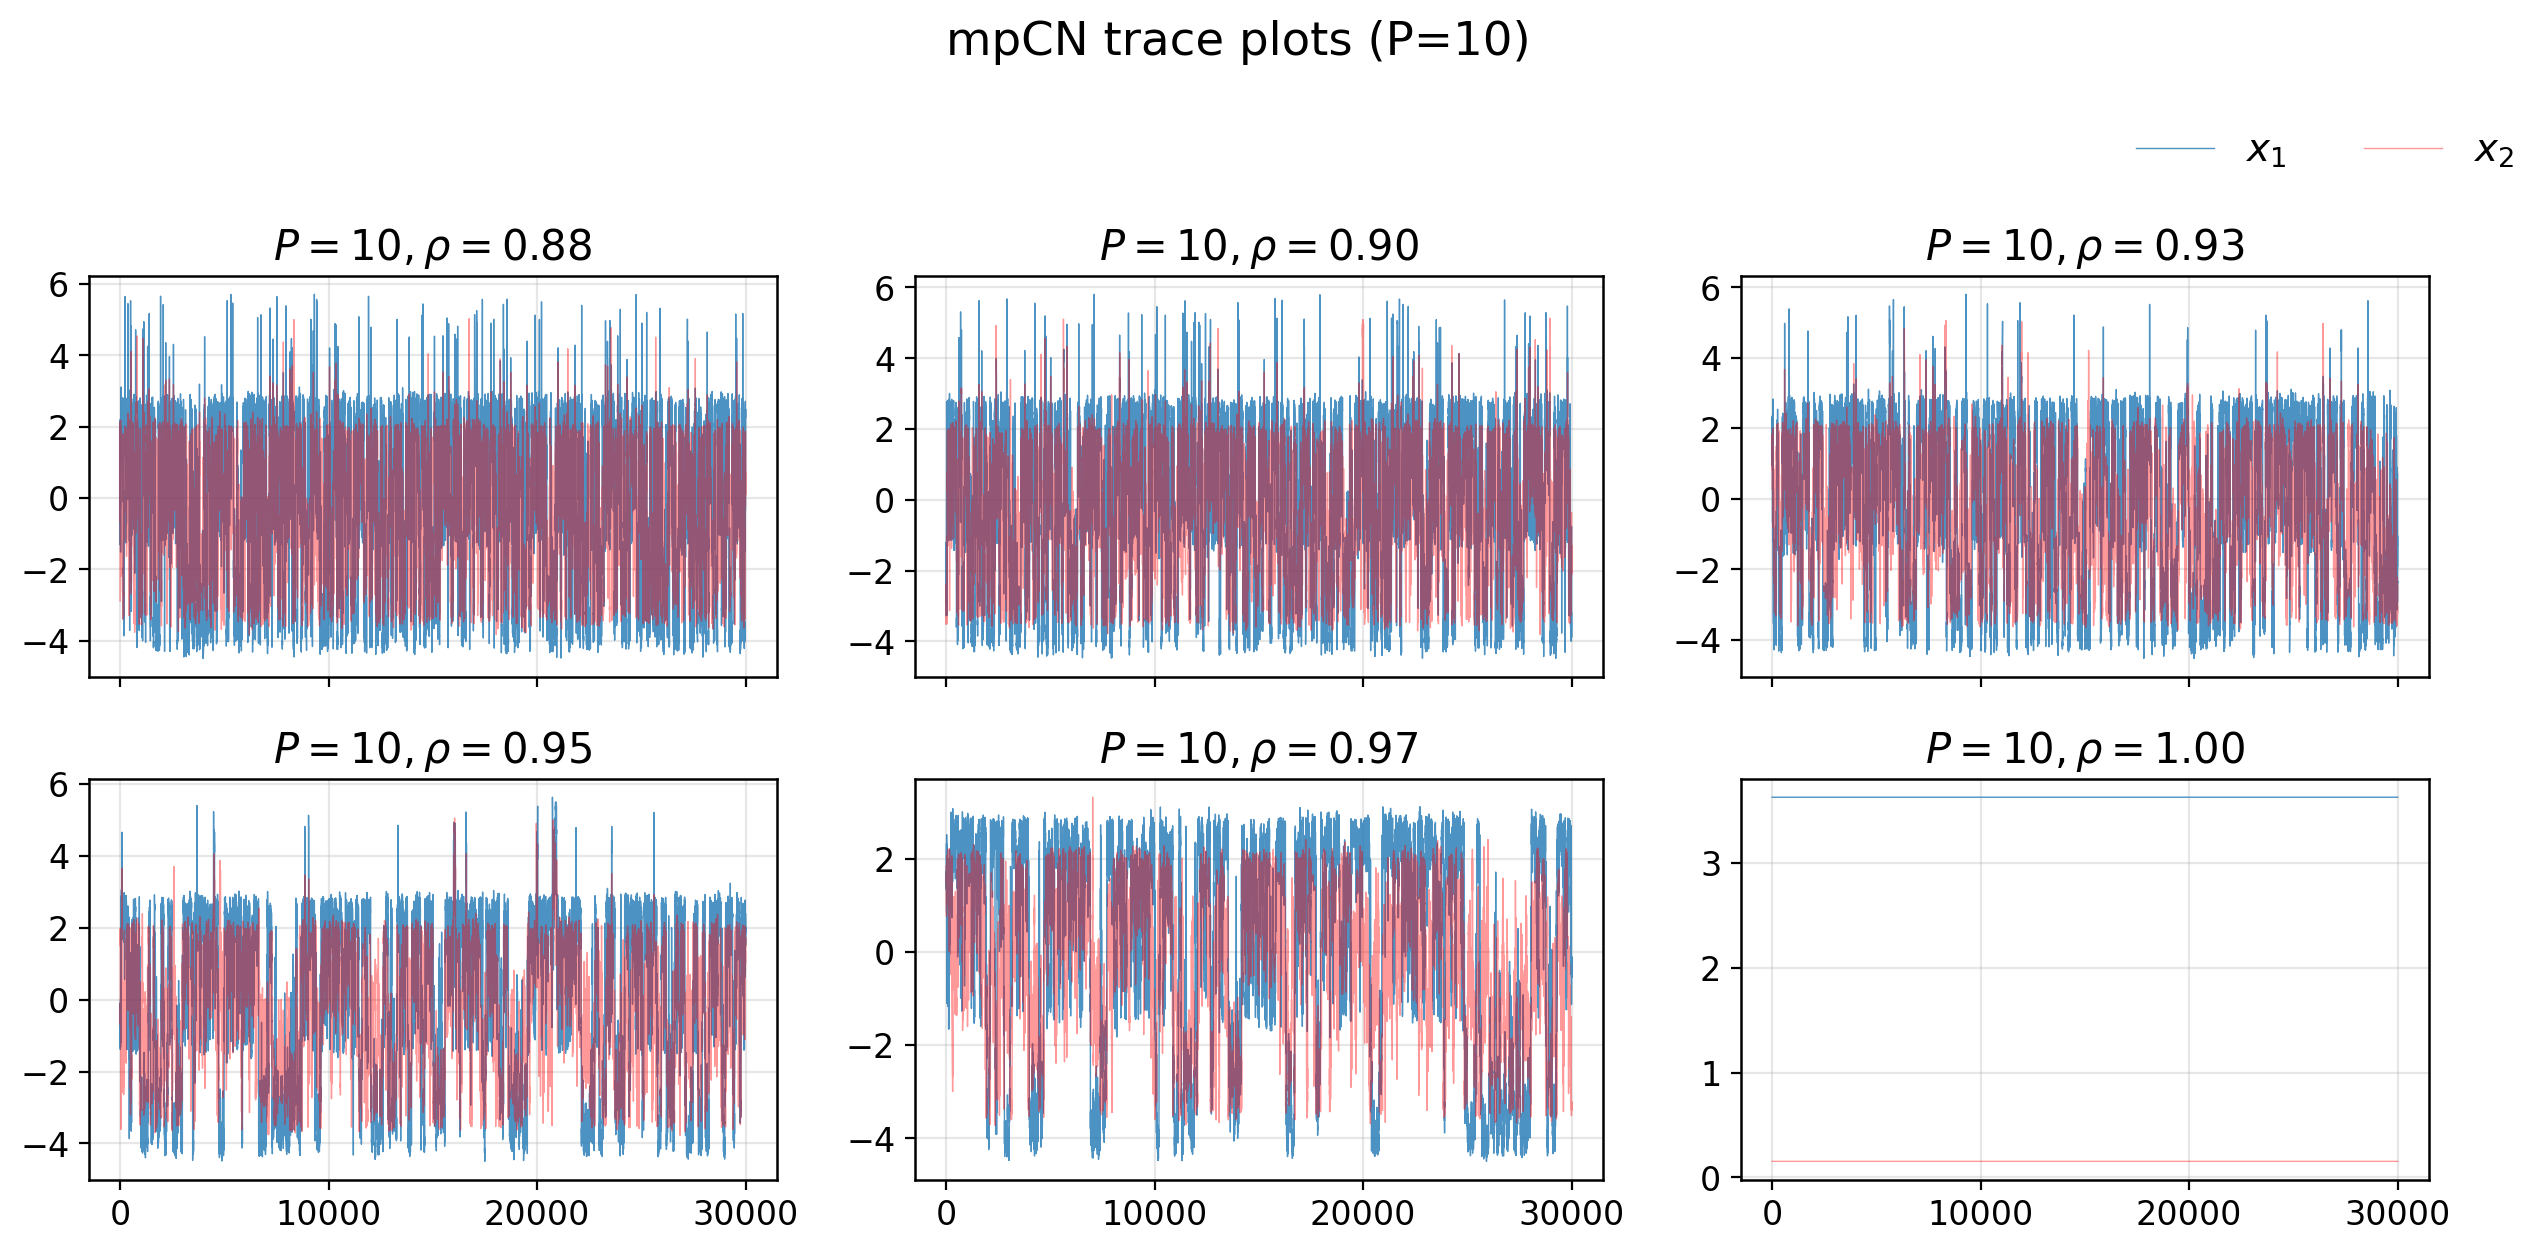

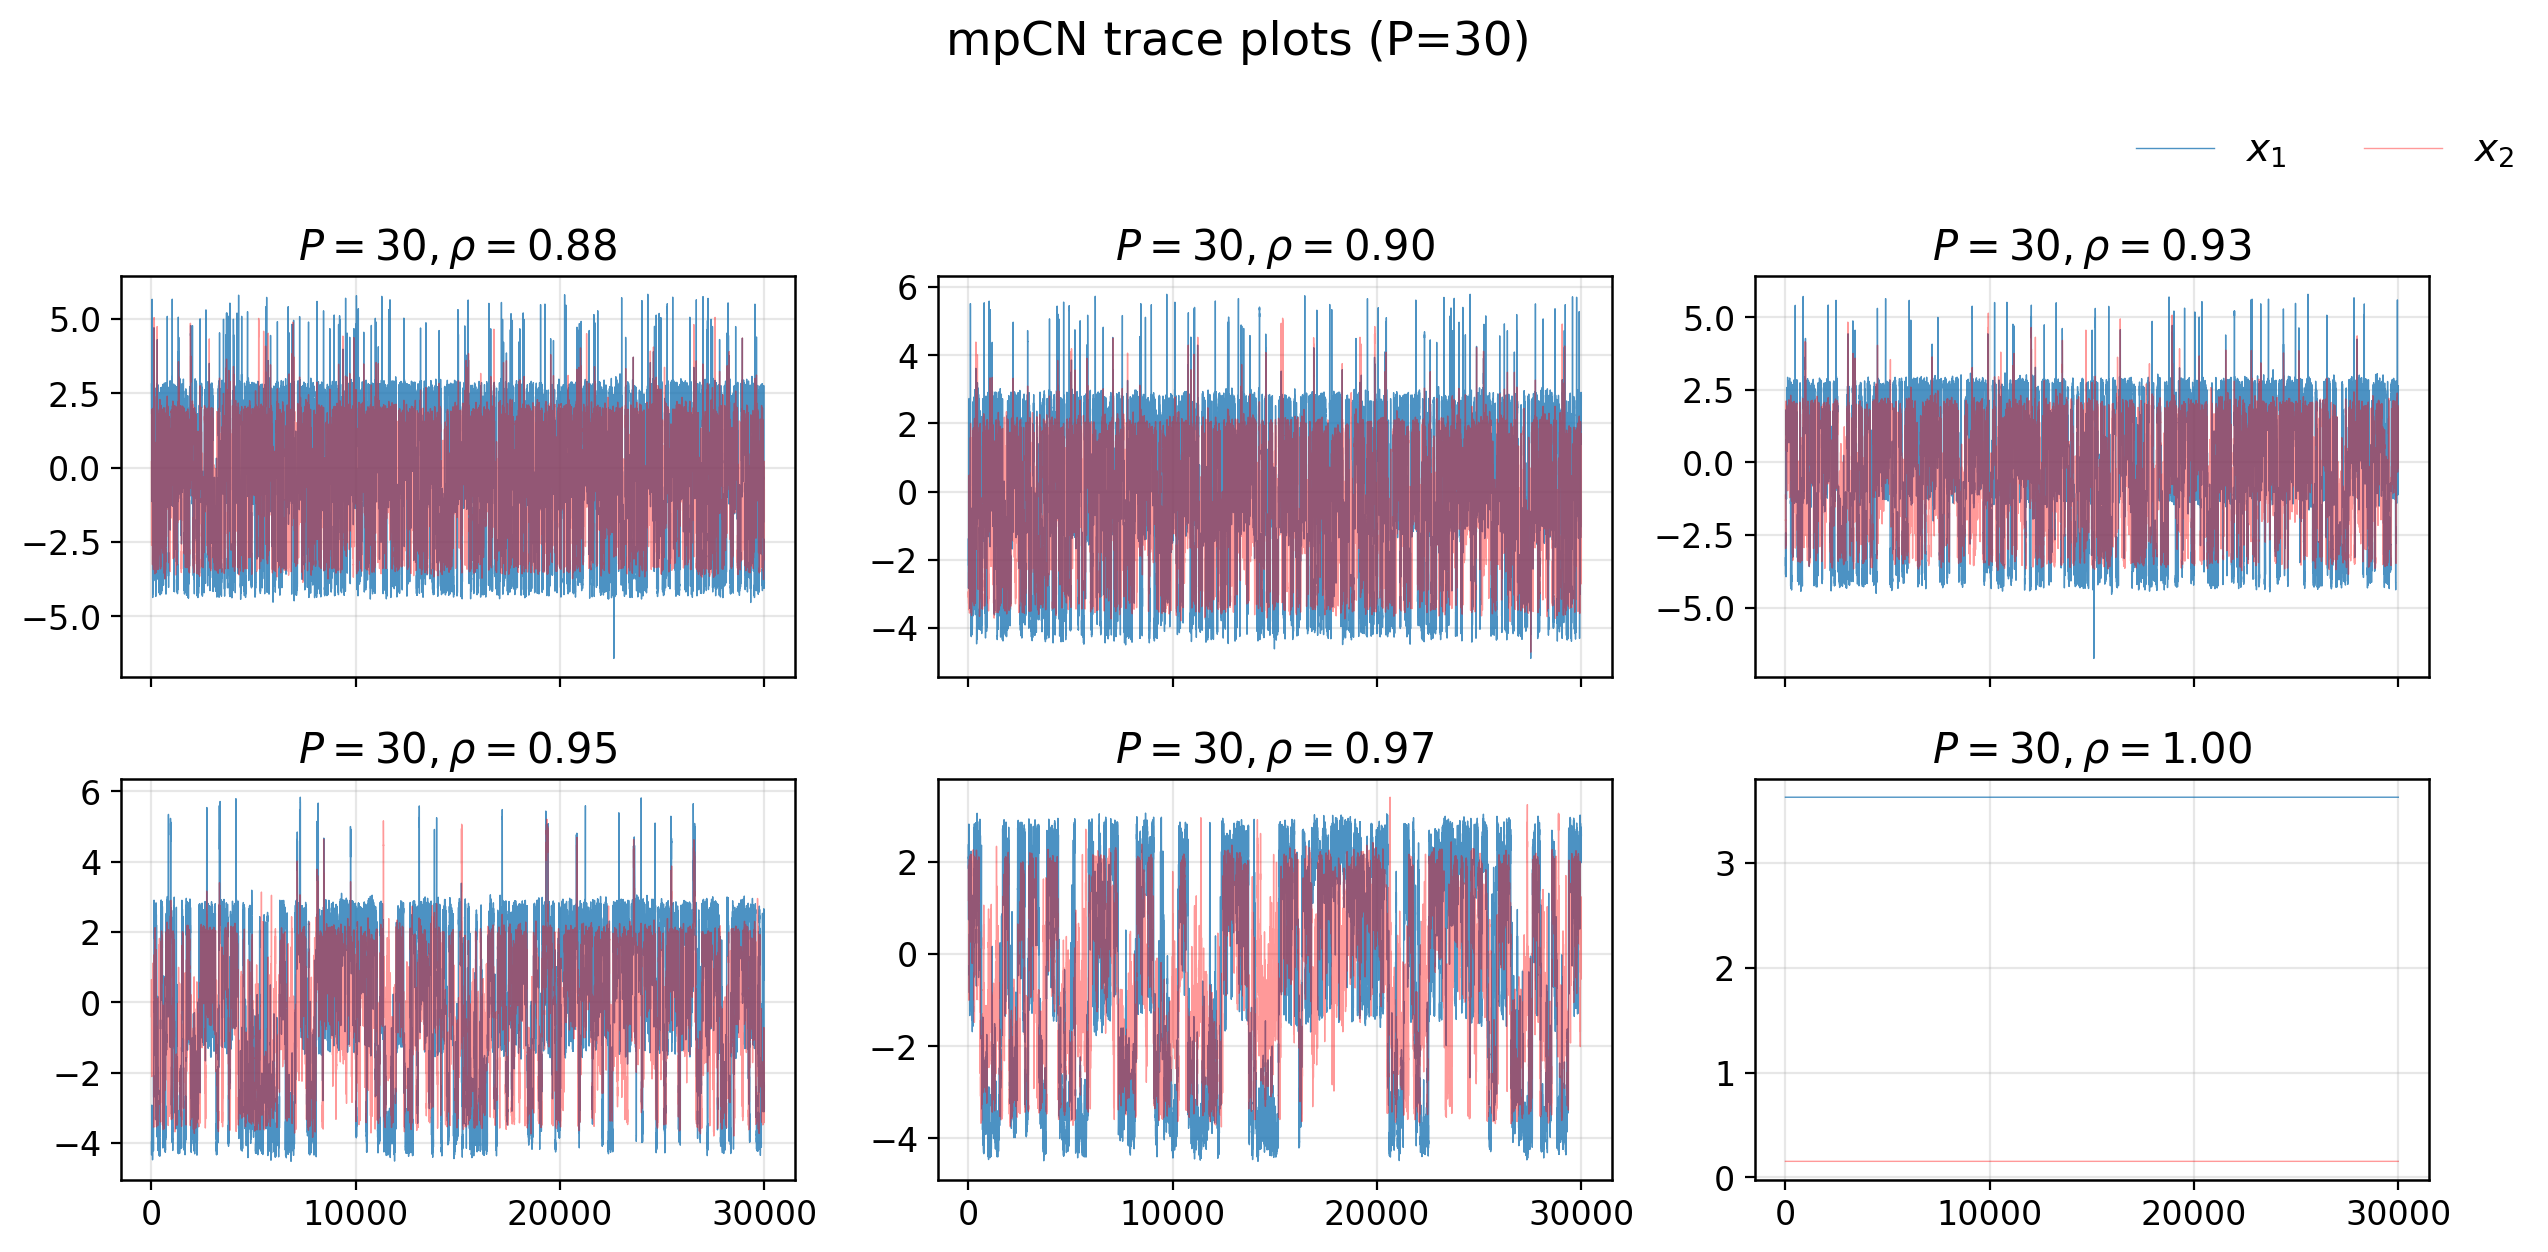

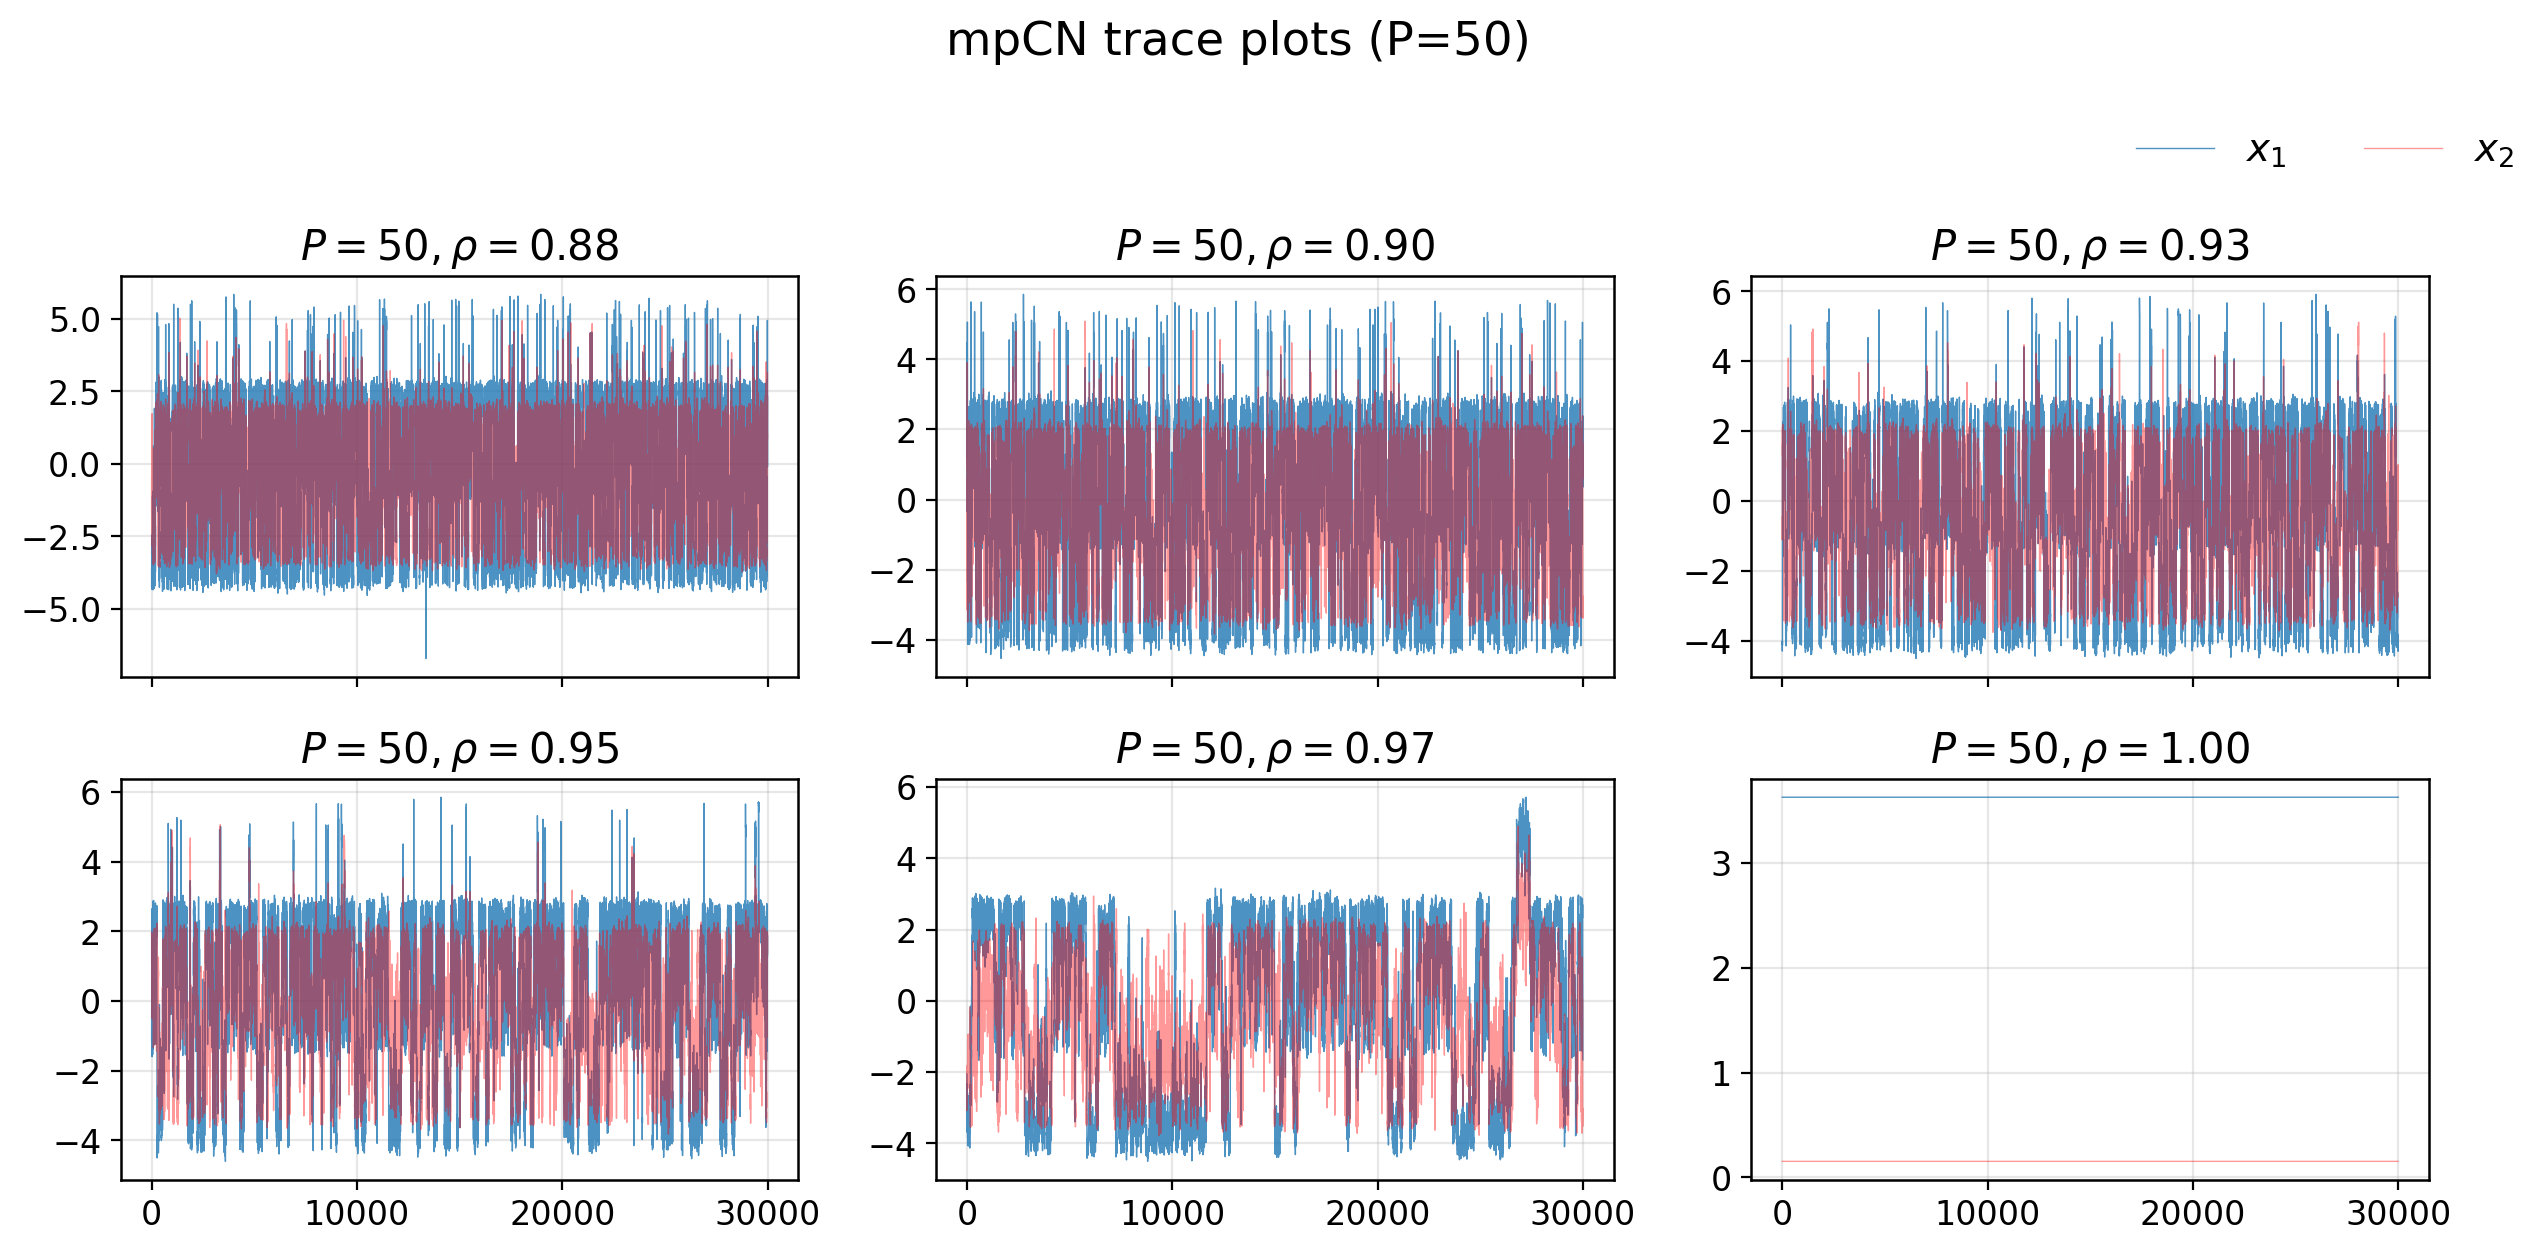

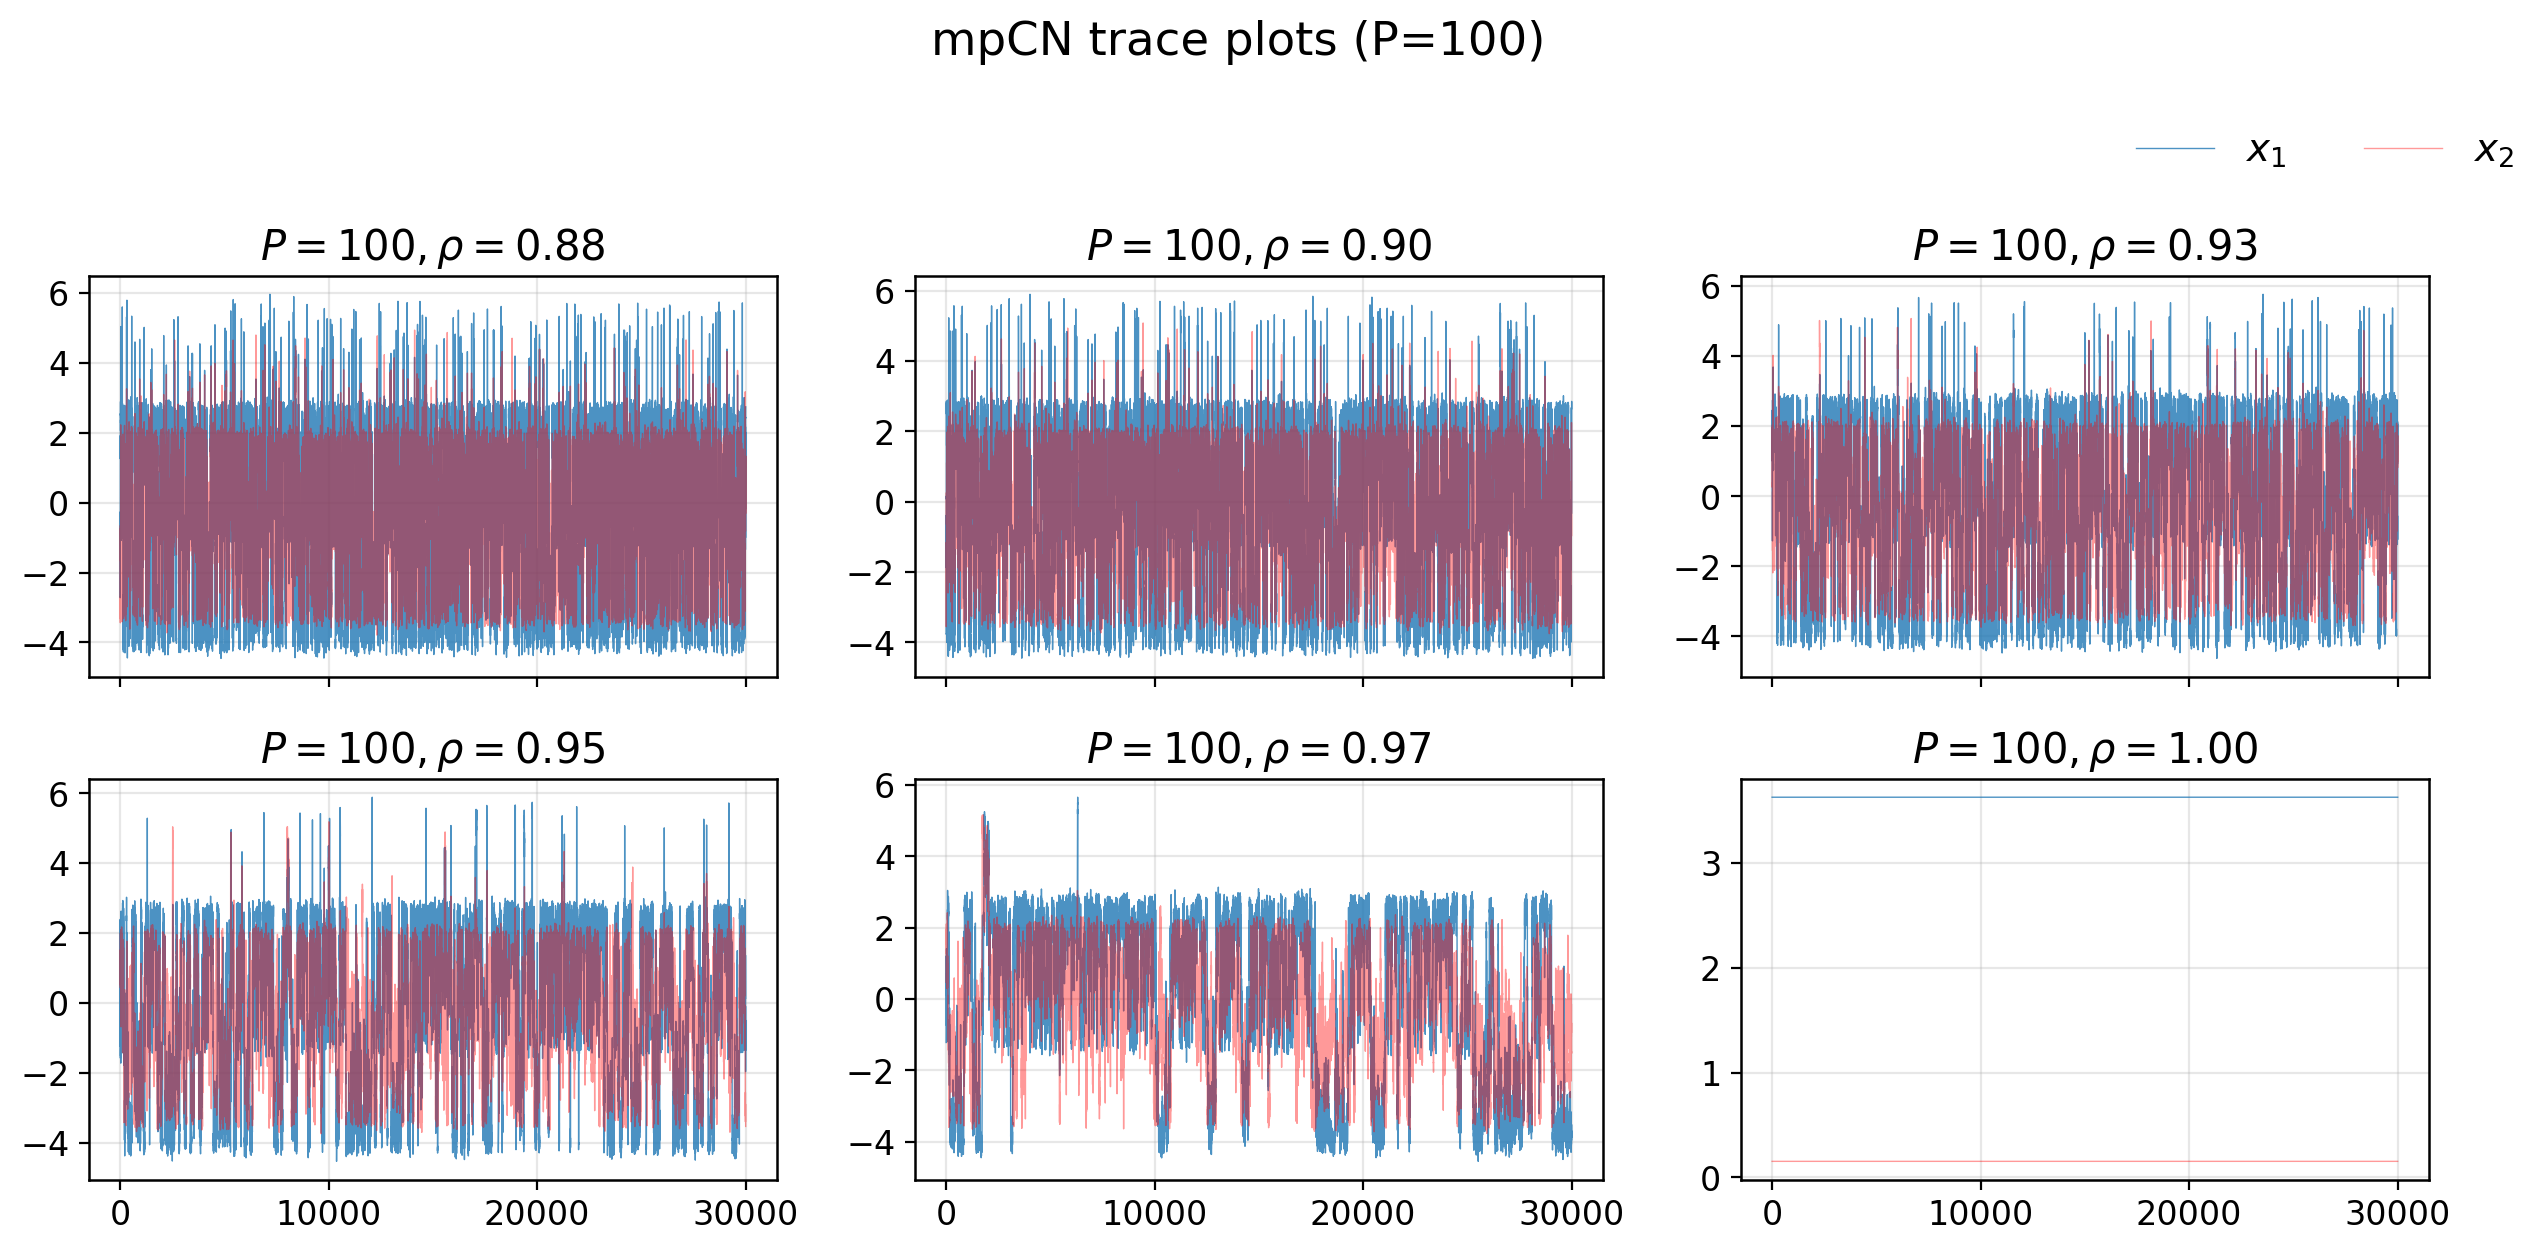

In [14]:
# Trace plots: one figure per P, subplots by rho
rho_list_plot = rho_list[-6:]  # plot only last 10 rhos to avoid overcrowding
weight_x_tag = str(weight_x).replace('.', 'p')
weight_y_tag = str(weight_y).replace('.', 'p')
plot_trace_grid(
    results,
    P_list=P_list,
    rho_list_plot=rho_list_plot,
    burn_in=burn_in,
    reports_dir=reports_dir,
    seed_base=seed_base,
    file_name_fmt="03_polar_twist_mpcn_traces_P{P}_last6_seed{seed_base}_wx{weight_x_tag}_wy{weight_y_tag}.png",
    file_name_kwargs={"weight_x_tag": weight_x_tag, "weight_y_tag": weight_y_tag},
    max_iters=30000,
 )

In [ ]:
# # Histograms: one figure per P, each rho has two subplots (x1, x2)
# bins = 40
# for P in P_list[:1]:
#     fig, axes = plt.subplots(len(rho_list_plot), 2, figsize=(10, 2.6 * len(rho_list_plot)), sharex='col')
#     for row_idx, rho in enumerate(rho_list_plot):
#         chain = results['mpcn'][P][rho]['chain'][burn_in:]
#         ax1 = axes[row_idx, 0]
#         ax2 = axes[row_idx, 1]
#         ax1.hist(chain[:, 0], bins=bins, density=True, color='#1f77b4', alpha=0.6)
#         ax2.hist(chain[:, 1], bins=bins, density=True, color='#5fa2ce', alpha=0.6)
#         ax1.set_title(f'P={P}, rho={rho:.3f}, x1')
#         ax2.set_title(f'P={P}, rho={rho:.3f}, x2')
#         ax1.grid(alpha=0.3)
#         ax2.grid(alpha=0.3)
#     fig.suptitle(f'mPCN histograms (P={P})')
#     fig.tight_layout()
#     plt.savefig(
#         reports_dir / f'03_polar_twist_mpcn_histograms_P{P}_last6_seed{seed_base}_wx{weight_x_tag}_wy{weight_y_tag}.png',
#         dpi=300,
#     )
#     plt.show()

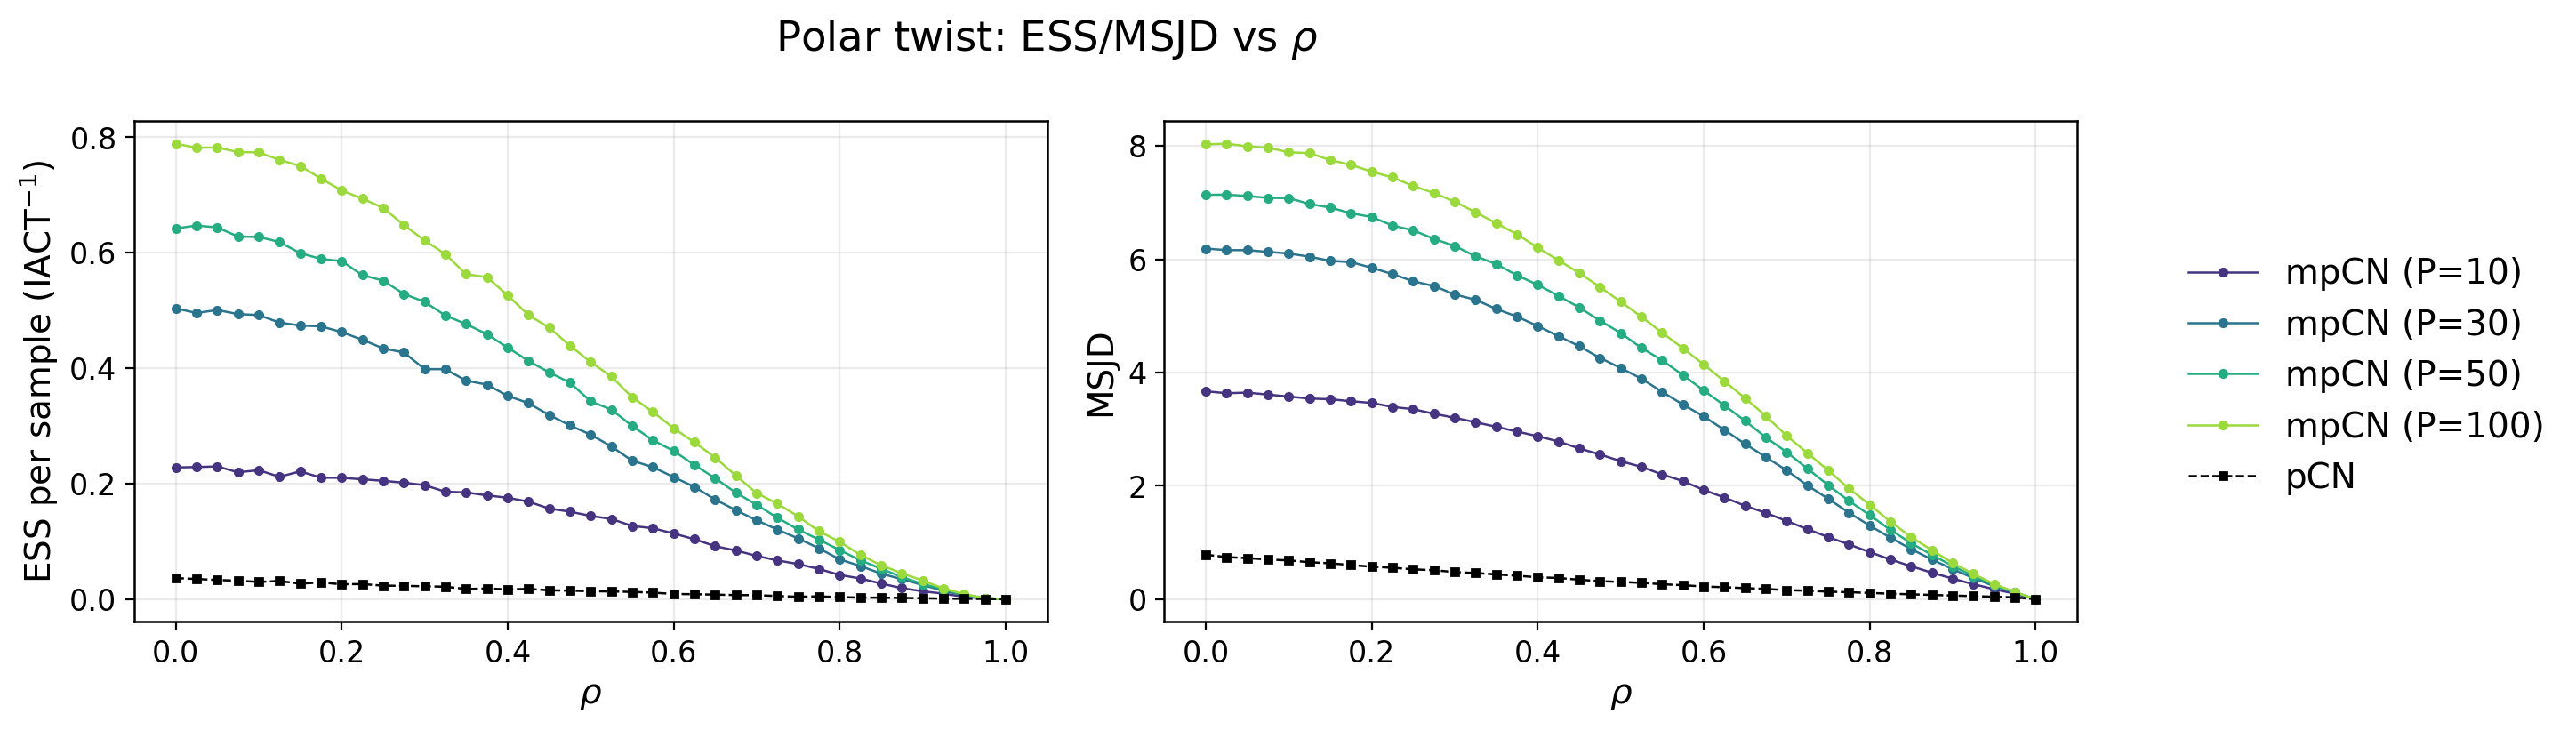

In [15]:
# ESS/MSJD vs rho curves (one line per P)
plot_ess_msjd_vs_rho(
    results,
    rho_list=rho_list,
    P_list=P_list,
    reports_dir=reports_dir,
    seed_base=seed_base,
    file_name_fmt="polar_twist_ess_msjd_vs_rho_seed{seed_base}_wx{weight_x_tag}_wy{weight_y_tag}.png",
    file_name_kwargs={"weight_x_tag": weight_x_tag, "weight_y_tag": weight_y_tag},
    run_pcn=run_pcn,
    run_mess=run_mess,
    burn_in=burn_in,
    show_mess=False,
    show_pcn=True,
    title_prefix="Polar twist",
    normalize_ess=True,
    share_y_metrics=False,
 )

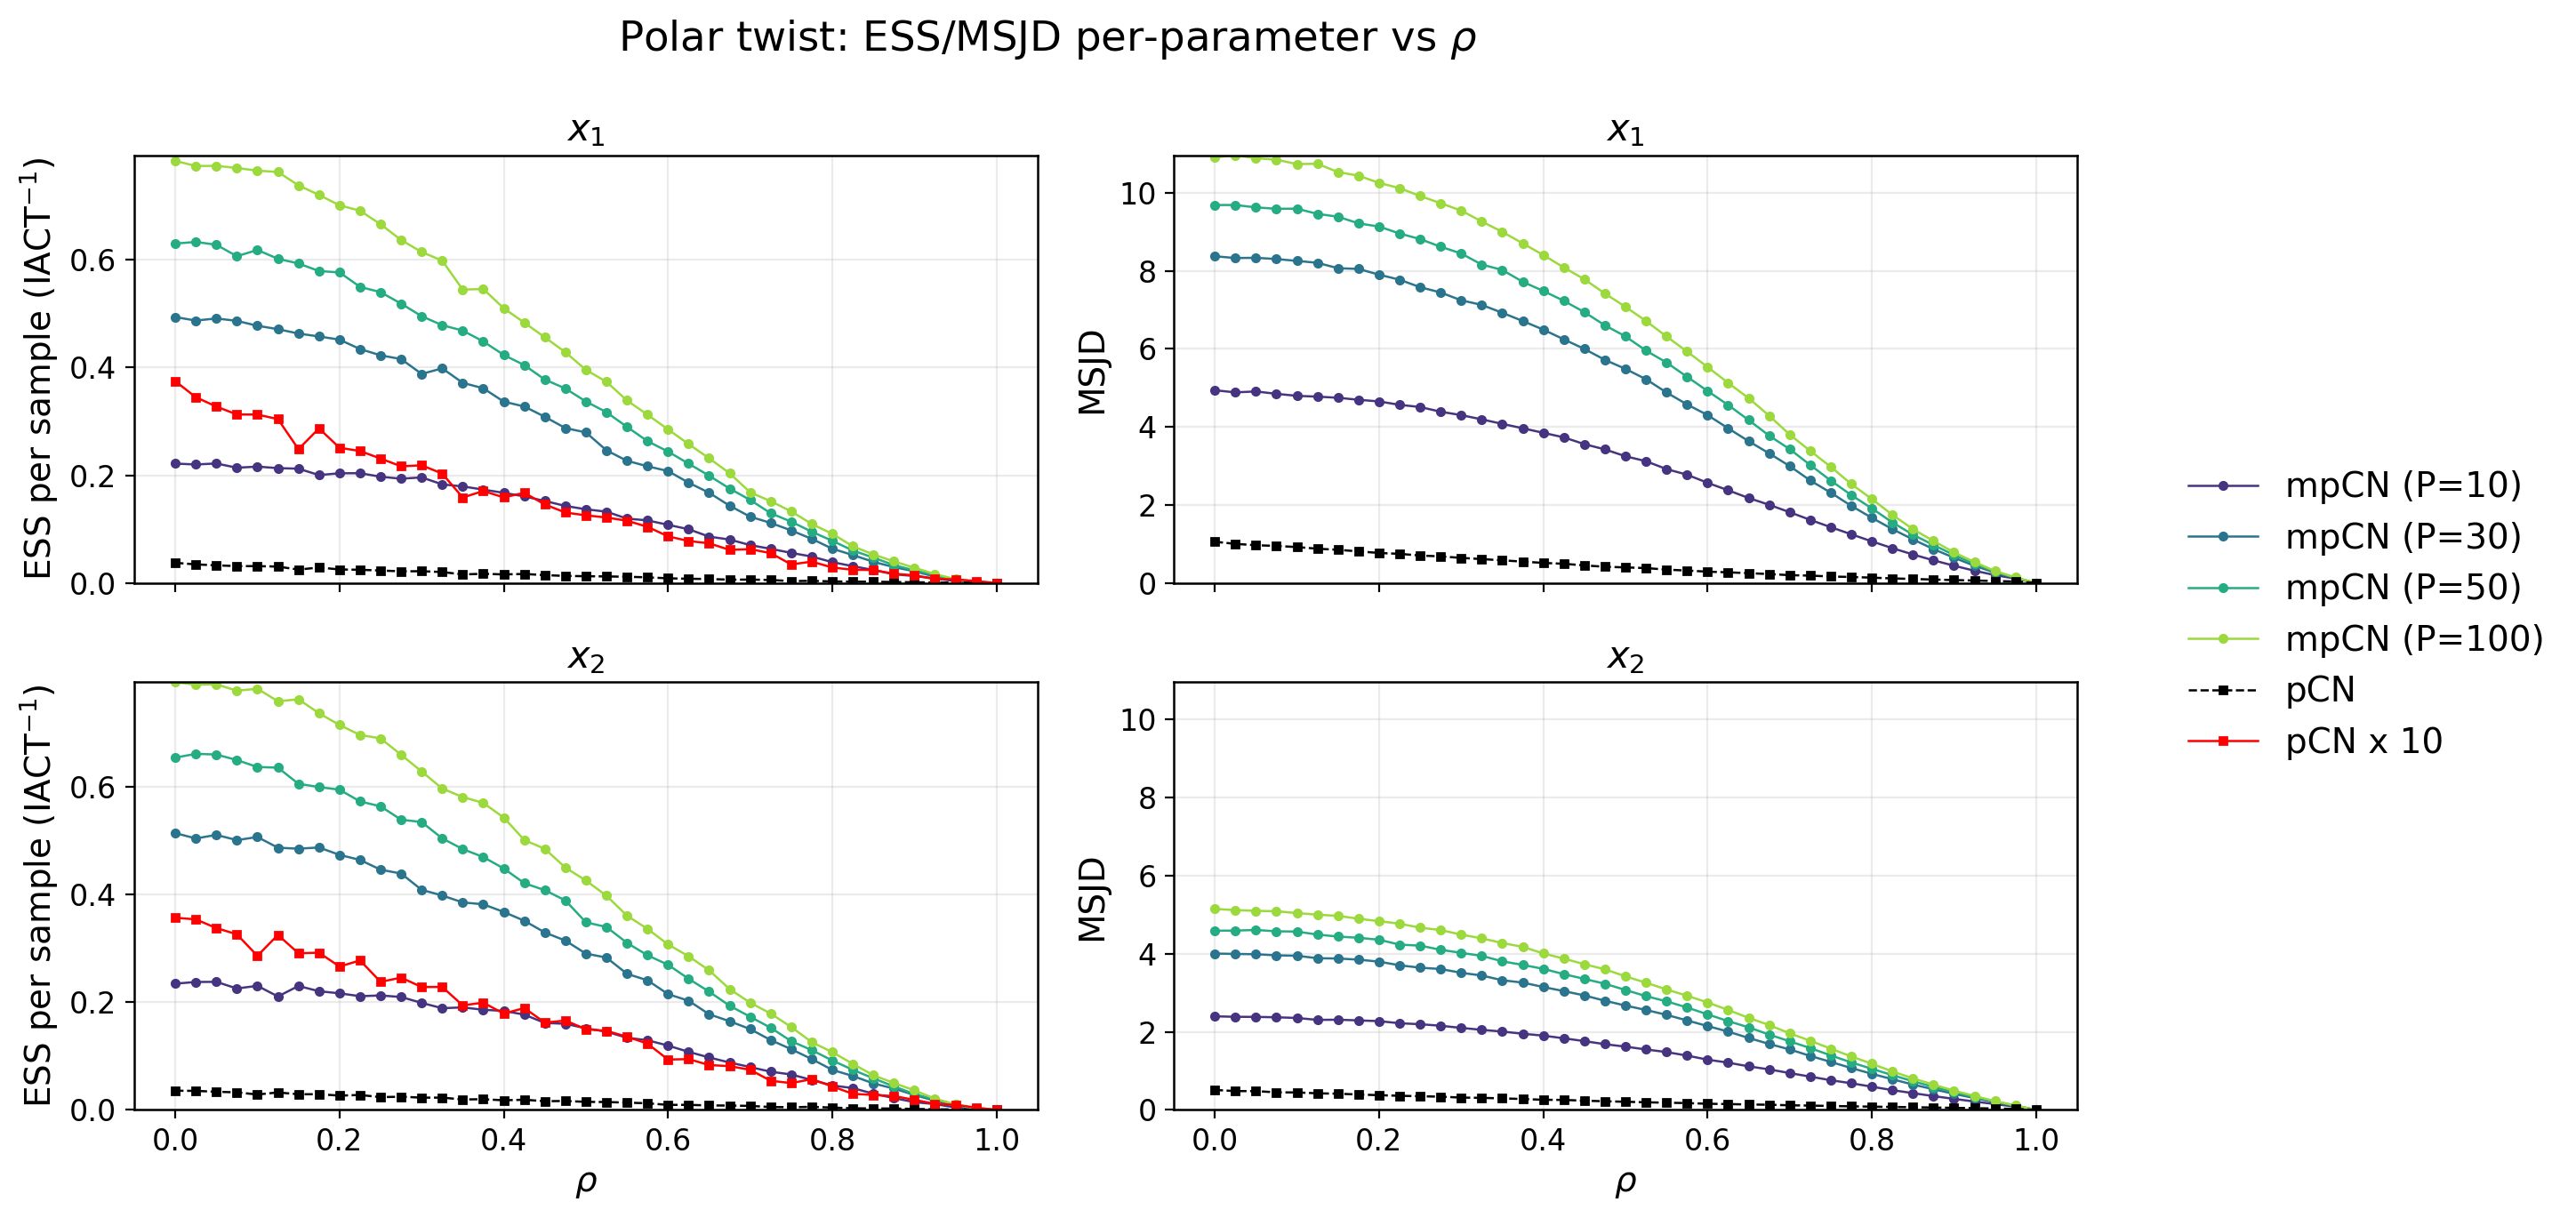

In [16]:
# ESS/MSJD per-parameter vs rho (full range + edges)
plot_ess_msjd_per_param_vs_rho(
    results,
    rho_list=rho_list,
    P_list=P_list,
    reports_dir=reports_dir,
    seed_base=seed_base,
    file_name_fmt="polar_twist_ess_msjd_per_param_vs_rho_seed{seed_base}_wx{weight_x_tag}_wy{weight_y_tag}.png",
    file_name_kwargs={"weight_x_tag": weight_x_tag, "weight_y_tag": weight_y_tag},
    run_pcn=run_pcn,
    burn_in=burn_in,
    show_pcn=True,
    title_prefix="Polar twist",
    pcn_scale=10,
    normalize_ess=True,
    share_y_metrics=True,
 )

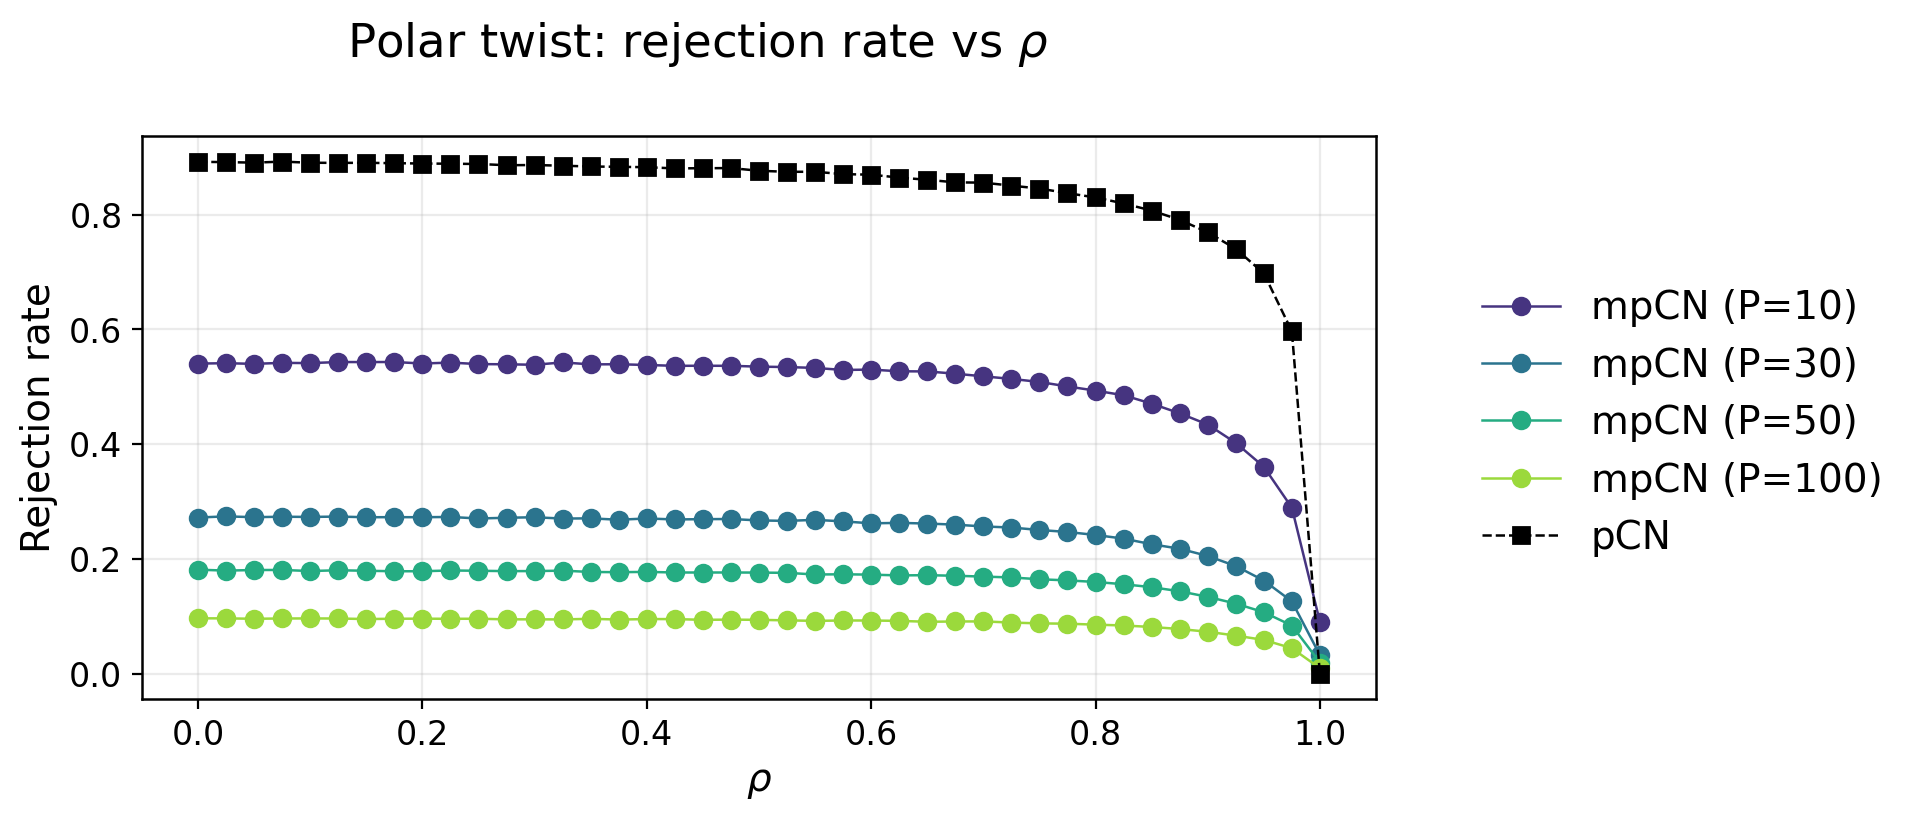

In [17]:
# Rejection rate vs rho (one line per P)
plot_rejection_vs_rho(
    results,
    rho_list=rho_list,
    P_list=P_list,
    reports_dir=reports_dir,
    seed_base=seed_base,
    file_name_fmt="polar_twist_rejection_vs_rho_seed{seed_base}_wx{weight_x_tag}_wy{weight_y_tag}.png",
    file_name_kwargs={"weight_x_tag": weight_x_tag, "weight_y_tag": weight_y_tag},
    run_pcn=run_pcn,
    show_pcn=True,
    title_prefix="Polar twist",
 )

In [18]:
# ESS/MSJD tables (rows=P, columns=rho + pCN)
ess_rows = []
msjd_rows = []
row_labels = []
col_labels = [f'rho={rho:.3f}' for rho in rho_list]

for P in P_list:
    ess_row = [results['mpcn'][P][rho]['metrics']['ess_mean'] for rho in rho_list]
    msjd_row = [results['mpcn'][P][rho]['metrics']['msjd_mean'] for rho in rho_list]
    ess_rows.append(ess_row)
    msjd_rows.append(msjd_row)
    row_labels.append(f'P={P}')

if run_pcn and results['pcn']:
    ess_row = [results['pcn'][rho]['metrics']['ess_mean'] for rho in rho_list]
    msjd_row = [results['pcn'][rho]['metrics']['msjd_mean'] for rho in rho_list]
    ess_rows.append(ess_row)
    msjd_rows.append(msjd_row)
    row_labels.append('pCN')

ess_table = pd.DataFrame(ess_rows, index=row_labels, columns=col_labels)
msjd_table = pd.DataFrame(msjd_rows, index=row_labels, columns=col_labels)

# display tables rounding up to 0 decimal places
ess_table_display = ess_table.round(0).astype(int)
msjd_table_display = msjd_table.round(3)
print('ESS table (mPCN across rho; pCN row if enabled):')
display(ess_table_display)
print('MSJD table (mPCN across rho; pCN row if enabled):')
display(msjd_table_display)

ESS table (mPCN across rho; pCN row if enabled):


,rho=0.000,rho=0.050,rho=0.100,rho=0.150,rho=0.200,rho=0.250,rho=0.300,rho=0.350,rho=0.400,rho=0.450,...,rho=0.550,rho=0.600,rho=0.650,rho=0.700,rho=0.750,rho=0.800,rho=0.850,rho=0.900,rho=0.950,rho=1.000
P=10,67270,67792,65854,65243,61970,60442,58221,54513,51793,46274,...,37386,33538,27054,22101,17950,12404,7995,4031,1193,0
P=30,148607,147741,145167,139822,136462,128114,117505,111627,103859,94087,...,70720,62354,50905,40284,31014,20347,13051,7281,2024,0
P=50,189402,189935,185081,176789,172727,162755,151880,140531,128545,115862,...,88486,75716,61770,48238,35611,25089,15587,7785,2384,0
P=100,232691,230752,228230,221314,208822,199948,183302,166014,155264,138756,...,103155,87363,72361,54177,42300,29293,17314,9515,2585,0
pCN,10788,9812,8832,7953,7628,6913,6587,5204,4981,4539,...,3709,2656,2315,2025,1243,1068,765,485,240,0


MSJD table (mPCN across rho; pCN row if enabled):


,rho=0.000,rho=0.050,rho=0.100,rho=0.150,rho=0.200,rho=0.250,rho=0.300,rho=0.350,rho=0.400,rho=0.450,...,rho=0.550,rho=0.600,rho=0.650,rho=0.700,rho=0.750,rho=0.800,rho=0.850,rho=0.900,rho=0.950,rho=1.000
P=10,3.669,3.646,3.576,3.529,3.464,3.353,3.202,3.043,2.876,2.660,...,2.201,1.927,1.647,1.379,1.095,0.831,0.581,0.363,0.176,0.0
P=30,6.189,6.161,6.102,5.972,5.850,5.612,5.378,5.123,4.821,4.465,...,3.659,3.226,2.739,2.272,1.772,1.298,0.883,0.530,0.231,0.0
P=50,7.138,7.118,7.080,6.913,6.747,6.511,6.234,5.915,5.549,5.148,...,4.215,3.684,3.145,2.594,2.010,1.482,0.987,0.586,0.249,0.0
P=100,8.027,7.992,7.889,7.750,7.544,7.292,7.018,6.637,6.206,5.758,...,4.702,4.144,3.547,2.882,2.272,1.668,1.095,0.640,0.267,0.0
pCN,0.785,0.725,0.684,0.633,0.573,0.527,0.480,0.438,0.387,0.343,...,0.264,0.224,0.195,0.160,0.133,0.110,0.086,0.064,0.042,0.0


## Analyzing mixing for extreme $\rho$

In [ ]:
# Run extra rho chains for the edge ranges
rho_low = np.round(np.arange(0.0, 0.1001, 0.005), 5)
rho_high = np.round(np.arange(0.85, 1.0001, 0.005), 5)
rho_edges = np.unique(np.concatenate([rho_low, rho_high]))

def ensure_mpcn_rho_results(rho_values):
    missing_edges = []
    for P in P_list:
        results['mpcn'].setdefault(P, {})
        for rho in rho_values:
            rho_key = float(rho)
            if rho_key in results['mpcn'][P]:
                continue
            samples_path, metrics_path = chain_cache_paths(
                'mpcn', rho=rho_key, seed_base=seed_base, P=P
            )
            diag_path = mpcn_diag_path(P, rho_key, seed_base)
            loaded = load_chain_bundle(samples_path, metrics_path)
            if loaded is None:
                missing_edges.append((P, rho_key))
                continue
            chain, accept_rate, runtime_sec, metrics = loaded
            if metrics is None or 'ess_per_param' not in metrics:
                metrics = summarize_chain_metrics(
                    chain, runtime_sec, burn_in=burn_in, max_lag=max_lag
                )
                save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec)
            snapshot, mean_dist_samples, mean_sq_dist_samples = load_mpcn_diagnostics(diag_path)
            results['mpcn'][P][rho_key] = {
                'chain': chain,
                'runtime_sec': runtime_sec,
                'accept_rate': accept_rate,
                'metrics': metrics,
                'snapshot': snapshot,
                'mean_dist_samples': np.asarray(mean_dist_samples, dtype=float),
                'mean_sq_dist_samples': np.asarray(mean_sq_dist_samples, dtype=float),
            }
            accept_display = np.nan if accept_rate is None else accept_rate
            print(
                f'mPCN edge rho loaded: P={P}, rho={rho_key:.3f}, '
                f'accept={accept_display:.3f}, runtime={runtime_sec:.2f}s'
            )
    return missing_edges

missing_edges = ensure_mpcn_rho_results(rho_edges)
if missing_edges:
    preview = "\n".join([f"P={P}, rho={rho:.3f}" for P, rho in missing_edges[:10]])
    job_dir = repo_root / "jobs" / "polar_twist" / f"{run_id}_data_{data_id}"
    raise RuntimeError(
        "Missing edge-rho chains. Run the job script to generate chains, then re-run this cell.\n"
        f"Job dir: {job_dir}\n"
        f"Example: bash {job_dir / 'launch_workers.sh'}\n"
        f"Missing ({len(missing_edges)}):\n{preview}"
    )

In [ ]:
# Zoomed-in rho ranges (0-0.1 and 0.9-1.0)
apply_pub_style()

rho_low = np.round(np.arange(0.0, 0.1001, 0.005), 5)
rho_high = np.round(np.arange(0.85, 1.0001, 0.005), 5)

P_sorted = sorted(P_list)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(P_sorted)))
color_by_P = {P: colors[i] for i, P in enumerate(P_sorted)}

def get_metric_for_rho(results_dict, P, rho, metric_key):
    entry = results_dict.get(P, {}).get(float(rho))
    if entry is None:
        return np.nan
    return entry['metrics'][metric_key]

reports_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), sharey=True)
ax_low, ax_high = axes

for P in P_sorted:
    ess_low = [get_metric_for_rho(results['mpcn'], P, rho, 'ess_mean') for rho in rho_low]
    ess_high = [get_metric_for_rho(results['mpcn'], P, rho, 'ess_mean') for rho in rho_high]
    ax_low.plot(rho_low, ess_low, marker='o', color=color_by_P[P], label=f'P={P}')
    ax_high.plot(rho_high, ess_high, marker='o', color=color_by_P[P], label=f'P={P}')

ax_low.set_title(r'ESS vs $\rho$ (0.0-0.1)')
ax_low.set_xlabel(r'$\rho$')
ax_low.set_ylabel('Effective Sample Size')
ax_low.grid(alpha=0.25)

ax_high.set_title(r'ESS vs $\rho$ (0.9-1.0)')
ax_high.set_xlabel(r'$\rho$')
ax_high.grid(alpha=0.25)

handles, labels = ax_low.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle(r'Polar twist: ESS at $\rho$ range edges')
fig.tight_layout()

filename = (
    f'polar_twist_ess_rho_edges_0.00-0.10_0.85-1.00_seed{seed_base}_'
    f'wx{weight_x_tag}_wy{weight_y_tag}.png'
 )
fig.savefig(reports_dir / filename, bbox_inches='tight')
plt.show()

In [ ]:
# Zoomed-in MSJD vs rho (0-0.1 and 0.9-1.0)
apply_pub_style()

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), sharey=True)
ax_low, ax_high = axes

for P in P_sorted:
    msjd_low = [get_metric_for_rho(results['mpcn'], P, rho, 'msjd_mean') for rho in rho_low]
    msjd_high = [get_metric_for_rho(results['mpcn'], P, rho, 'msjd_mean') for rho in rho_high]
    ax_low.plot(rho_low, msjd_low, marker='o', color=color_by_P[P], label=f'P={P}')
    ax_high.plot(rho_high, msjd_high, marker='o', color=color_by_P[P], label=f'P={P}')

ax_low.set_title(r'MSJD vs $\rho$ (0.0-0.1)')
ax_low.set_xlabel(r'$\rho$')
ax_low.set_ylabel('MSJD')
ax_low.grid(alpha=0.25)

ax_high.set_title(r'MSJD vs $\rho$ (0.9-1.0)')
ax_high.set_xlabel(r'$\rho$')
ax_high.grid(alpha=0.25)

handles, labels = ax_low.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle(r'Polar twist: MSJD at $\rho$ range edges')
fig.tight_layout()

filename = (
    f'polar_twist_msjd_rho_edges_0.00-0.10_0.85-1.00_seed{seed_base}_'
    f'wx{weight_x_tag}_wy{weight_y_tag}.png'
 )
fig.savefig(reports_dir / filename, bbox_inches='tight')
plt.show()

In [ ]:

# Edge rho ranges combined
rho_low = np.round(np.arange(0.0, 0.1001, 0.005), 5)
rho_high = np.round(np.arange(0.85, 1.0001, 0.005), 5)
rho_edges = np.unique(np.concatenate([rho_low, rho_high]))
rho_edges = rho_high

fig, axes = plt.subplots(2, 2, figsize=(12.0, 7.0), sharex=True)
for P in P_sorted:
    ess_x1 = [get_param_metric(results['mpcn'], P, rho, 'ess_per_param', 0) for rho in rho_edges]
    ess_x2 = [get_param_metric(results['mpcn'], P, rho, 'ess_per_param', 1) for rho in rho_edges]
    msjd_x1 = [get_param_metric(results['mpcn'], P, rho, 'msjd_per_param', 0) for rho in rho_edges]
    msjd_x2 = [get_param_metric(results['mpcn'], P, rho, 'msjd_per_param', 1) for rho in rho_edges]
    axes[0, 0].plot(rho_edges, ess_x1, marker='o', color=color_by_P[P], label=f'mPCN P={P}')
    axes[1, 0].plot(rho_edges, ess_x2, marker='o', color=color_by_P[P])
    axes[0, 1].plot(rho_edges, msjd_x1, marker='o', color=color_by_P[P])
    axes[1, 1].plot(rho_edges, msjd_x2, marker='o', color=color_by_P[P])

axes[0, 0].set_title('ESS (x1) edges')
axes[0, 1].set_title('MSJD (x1) edges')
axes[1, 0].set_title('ESS (x2) edges')
axes[1, 1].set_title('MSJD (x2) edges')
for ax in axes[1, :]:
    ax.set_xlabel(r'$\rho$')
axes[0, 0].set_ylabel('ESS')
axes[1, 0].set_ylabel('ESS')
axes[0, 1].set_ylabel('MSJD')
axes[1, 1].set_ylabel('MSJD')
for ax in axes.ravel():
    ax.grid(alpha=0.25)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle(r'Polar twist: ESS/MSJD per-parameter at $\rho$ edges')
fig.tight_layout()
fig.savefig(
    reports_dir / f'polar_twist_ess_msjd_per_param_rho_edges_0.85-1.00_seed{seed_base}_wx{weight_x_tag}_wy{weight_y_tag}.png',
    bbox_inches='tight',
)
plt.show()

In [ ]:
# Rejection rate vs rho (edge ranges)
apply_pub_style()

rho_low = np.round(np.arange(0.0, 0.1001, 0.005), 5)
rho_high = np.round(np.arange(0.85, 1.0001, 0.005), 5)

P_sorted = sorted(P_list)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(P_sorted)))
color_by_P = {P: colors[i] for i, P in enumerate(P_sorted)}

def get_reject_rate(results_dict, P, rho):
    entry = results_dict.get(P, {}).get(float(rho))
    if entry is None:
        return np.nan
    accept_rate = entry.get('accept_rate')
    if accept_rate is None:
        return np.nan
    return 1.0 - accept_rate

reports_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), sharey=True)
ax_low, ax_high = axes

for P in P_sorted:
    reject_low = [get_reject_rate(results['mpcn'], P, rho) for rho in rho_low]
    reject_high = [get_reject_rate(results['mpcn'], P, rho) for rho in rho_high]
    ax_low.plot(rho_low, reject_low, marker='o', color=color_by_P[P], label=f'P={P}')
    ax_high.plot(rho_high, reject_high, marker='o', color=color_by_P[P], label=f'P={P}')

ax_low.set_title(r'Rejection rate vs $\rho$ (0.0-0.1)')
ax_low.set_xlabel(r'$\rho$')
ax_low.set_ylabel('Rejection rate')
ax_low.grid(alpha=0.25)

ax_high.set_title(r'Rejection rate vs $\rho$ (0.9-1.0)')
ax_high.set_xlabel(r'$\rho$')
ax_high.grid(alpha=0.25)

handles, labels = ax_low.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle(r'Polar twist: rejection rate at $\rho$ range edges')
fig.tight_layout()

filename = (
    f'polar_twist_rejection_rho_edges_0.00-0.10_0.85-1.00_seed{seed_base}_'
    f'wx{weight_x_tag}_wy{weight_y_tag}.png'
 )
fig.savefig(reports_dir / filename, bbox_inches='tight')
plt.show()